In [8]:
# type: ignore

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

In [9]:
# ==========================================
# 2. Loading
# ==========================================
df = pd.read_csv("Fifa.csv")
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


# EDA

In [10]:
# Dataset Overview
print("Dataset Shape:", df.shape)

Dataset Shape: (19667, 9)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [12]:
# Basic Statistics
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [13]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
# Unique Values for Categorical Columns
print("Unique Countries:", df['Country'].nunique())
print("Unique Positions:", df['Position'].nunique())
print("Unique Teams:", df['Team'].nunique())
print("\nPosition Distribution:")
print(df['Position'].value_counts().head(10))

Unique Countries: 164
Unique Positions: 17
Unique Teams: 1009

Position Distribution:
Position
CB     2981
ST     2697
CM     2507
GK     2124
CDM    1358
LM     1279
RM     1203
RB     1100
CAM    1099
LB     1073
Name: count, dtype: int64


In [15]:
# Check for potential outliers in numerical columns
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
print("Outlier Detection (using IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers")

Outlier Detection (using IQR method):
Age: 169 outliers
Overall_Rating: 146 outliers
Future Potential: 120 outliers
Value Per M$: 2390 outliers
Total_Stats Score: 788 outliers


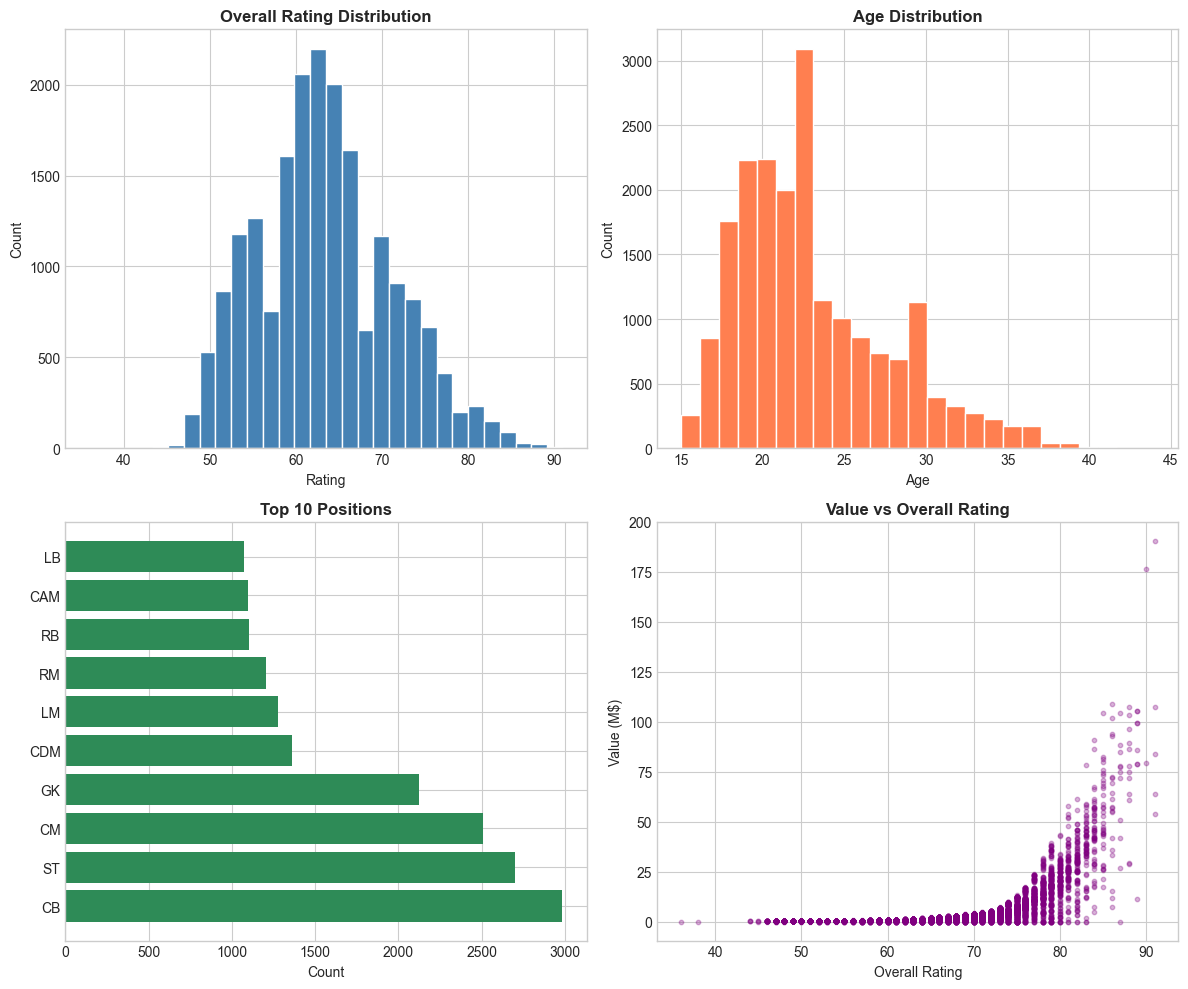

In [16]:

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Overall Rating Distribution
axes[0, 0].hist(df['Overall_Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Overall Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution
axes[0, 1].hist(df['Age'], bins=25, color='coral', edgecolor='white')
axes[0, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

# 3. Top 10 Positions
pos_counts = df['Position'].value_counts().head(10)
axes[1, 0].barh(pos_counts.index, pos_counts.values, color='seagreen')
axes[1, 0].set_title('Top 10 Positions', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Value vs Overall Rating
axes[1, 1].scatter(df['Overall_Rating'], df['Value Per M$'], alpha=0.3, s=10, color='purple')
axes[1, 1].set_title('Value vs Overall Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Rating')
axes[1, 1].set_ylabel('Value (M$)')

plt.tight_layout()
plt.show()

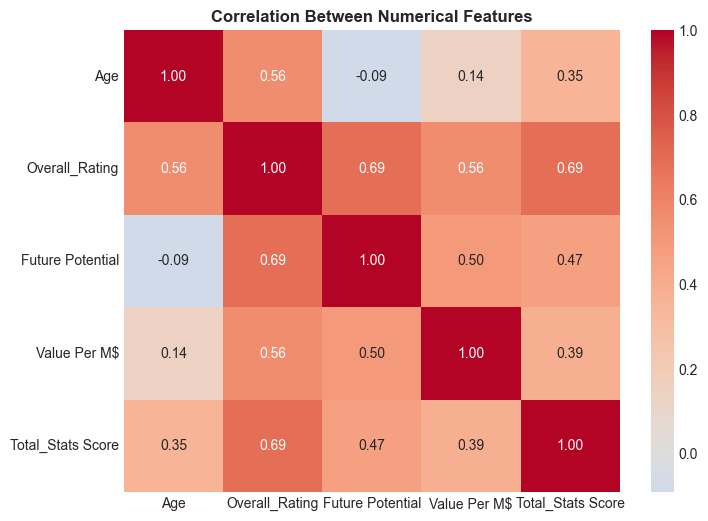

In [17]:
# Correlation Heatmap
numerical_df = df[['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']]
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numerical Features', fontsize=12, fontweight='bold')
plt.show()

In [18]:
# Missing values, skewness, correlation, and average rating per position
print("=== Missing Values by Column ===")
missing_counts = df.isnull().sum()
print(missing_counts)
print(f"Total missing values in dataset: {int(missing_counts.sum())}\n")

print("=== Skewness of Value Per M$ ===")
value_skew = df['Value Per M$'].skew()
print(f"Skewness(Value Per M$): {value_skew:.4f}")
if value_skew > 0:
    print("Interpretation: Right-skewed distribution (long right tail).\n")
elif value_skew < 0:
    print("Interpretation: Left-skewed distribution (long left tail).\n")
else:
    print("Interpretation: Approximately symmetric.\n")

print("=== Numerical Features Correlation with Value Per M$ ===")
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Value Per M$']
corr_with_value = df[num_cols].corr()['Value Per M$'].sort_values(ascending=False)
print(corr_with_value, "\n")

print("=== Average Overall_Rating per Position (Top 10) ===")
avg_rating_per_position = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating_per_position.head(10))

=== Missing Values by Column ===
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64
Total missing values in dataset: 0

=== Skewness of Value Per M$ ===
Skewness(Value Per M$): 7.9832
Interpretation: Right-skewed distribution (long right tail).

=== Numerical Features Correlation with Value Per M$ ===
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64 

=== Average Overall_Rating per Position (Top 10) ===
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
Name: Overall_Rating, dtype: float64


# Preprocessing

In [19]:
# ── Classification target ────────────────────────────────────────────────────
def assign_tier(rating):
    if rating >= 85: return 'Elite'
    elif rating >= 75: return 'High'
    elif rating >= 65: return 'Mid'
    else: return 'Low'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

tier_order = ['Low', 'Mid', 'High', 'Elite']
df['Performance_Tier'] = pd.Categorical(df['Performance_Tier'],
                                        categories=tier_order, ordered=True)

print("Performance Tier distribution:")
print(df['Performance_Tier'].value_counts().sort_index())

# ── Regression target ────────────────────────────────────────────────────────
# Log-transform to handle right skew
df['Value_log'] = np.log1p(df['Value Per M$'])

Performance Tier distribution:
Performance_Tier
Low      11740
Mid       6124
High      1711
Elite       92
Name: count, dtype: int64


In [20]:
# Targets to exclude from X
REGRESSION_TARGET   = 'Value_log'          # log-transformed
CLASSIFICATION_TARGET = 'Performance_Tier'

TARGET_COLS = ['Value Per M$', 'Value_log',
               'Performance_Tier', 'Overall_Rating']  # Overall_Rating defines tiers

# Feature groups
num_features      = ['Age', 'Future Potential', 'Total_Stats Score']


low_card_cat  = ['Position']
high_card_cat = ['Country', 'Team']


num_features_reg = num_features + ['Overall_Rating']


num_features_clf = num_features

print("Numerical features (regression) :", num_features_reg)
print("Numerical features (classif.)   :", num_features_clf)
print("Low-cardinality categoricals    :", low_card_cat)
print("High-cardinality categoricals   :", high_card_cat)

Numerical features (regression) : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
Numerical features (classif.)   : ['Age', 'Future Potential', 'Total_Stats Score']
Low-cardinality categoricals    : ['Position']
High-cardinality categoricals   : ['Country', 'Team']


In [21]:
RANDOM_STATE = 42

# ── Features ─────────────────────────────────────────────────────────────────
all_features = num_features_reg + low_card_cat

X = df[all_features].copy()
y_reg = df[REGRESSION_TARGET].copy()
y_clf = df[CLASSIFICATION_TARGET].copy()

# ── Stratified split (based on classification target) ────────────────────────
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print(f"Train size : {len(X_train):,}  ({len(X_train)/len(X):.0%})")
print(f"Test size  : {len(X_test):,}   ({len(X_test)/len(X):.0%})")
print()
print("Tier distribution — train:")
print(y_clf_train.value_counts().sort_index())
print()
print("Tier distribution — test:")
print(y_clf_test.value_counts().sort_index())

Train size : 15,733  (80%)
Test size  : 3,934   (20%)

Tier distribution — train:
Performance_Tier
Low      9392
Mid      4899
High     1369
Elite      73
Name: count, dtype: int64

Tier distribution — test:
Performance_Tier
Low      2348
Mid      1225
High      342
Elite      19
Name: count, dtype: int64


In [22]:
# Outlier handling via IQR capping (fit on train only to prevent leakage)
def cap_outliers_iqr(train_df, test_df, numeric_cols, whisker=1.5):
    train_capped = train_df.copy()
    test_capped = test_df.copy()

    for col in numeric_cols:
        q1 = train_df[col].quantile(0.25)
        q3 = train_df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - whisker * iqr
        upper = q3 + whisker * iqr

        train_capped[col] = train_df[col].clip(lower=lower, upper=upper)
        test_capped[col] = test_df[col].clip(lower=lower, upper=upper)

    return train_capped, test_capped

# Apply capping on numerical columns used by models
numeric_cols_for_capping = sorted(set(num_features_reg + num_features_clf))
X_train, X_test = cap_outliers_iqr(X_train, X_test, numeric_cols_for_capping)

print("Outlier handling applied with IQR capping on:", numeric_cols_for_capping)

Outlier handling applied with IQR capping on: ['Age', 'Future Potential', 'Overall_Rating', 'Total_Stats Score']


In [23]:
# ── Sub-pipelines ──────────────────────────────────────────────────
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # robust to skew / outliers
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer for REGRESSION ─────────────────────────────────────────
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_reg),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'   # silently drops any column not listed
)

# ── ColumnTransformer for CLASSIFICATION ─────────────────────────────────────
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_clf),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'
)

print("Preprocessors defined ✓")
print()
print("Regression  preprocessor inputs :", num_features_reg + low_card_cat)
print("Classification preprocessor inputs:", num_features_clf + low_card_cat)

Preprocessors defined ✓

Regression  preprocessor inputs : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating', 'Position']
Classification preprocessor inputs: ['Age', 'Future Potential', 'Total_Stats Score', 'Position']


In [24]:
# ── Fit on TRAIN only  ──────────────────────────────────────────────
X_train_reg = preprocessor_reg.fit_transform(X_train)
X_test_reg  = preprocessor_reg.transform(X_test)

X_train_clf = preprocessor_clf.fit_transform(X_train)
X_test_clf  = preprocessor_clf.transform(X_test)

# ── Feature names after encoding ──────────────────────────────────────────────
feature_names_reg = preprocessor_reg.get_feature_names_out()
feature_names_clf = preprocessor_clf.get_feature_names_out()

print("=== Regression ===")
print(f"  X_train shape : {X_train_reg.shape}")

print()
print("=== Classification ===")
print(f"  X_train shape : {X_train_clf.shape}")

=== Regression ===
  X_train shape : (15733, 20)

=== Classification ===
  X_train shape : (15733, 19)


=== Overall_Rating Percentiles (for threshold justification) ===
0.25    58.0
0.50    63.0
0.75    68.0
Name: Overall_Rating, dtype: float64

Chosen thresholds in notebook:
Low: < 65, Mid: 65-74, High: 75-84, Elite: >= 85


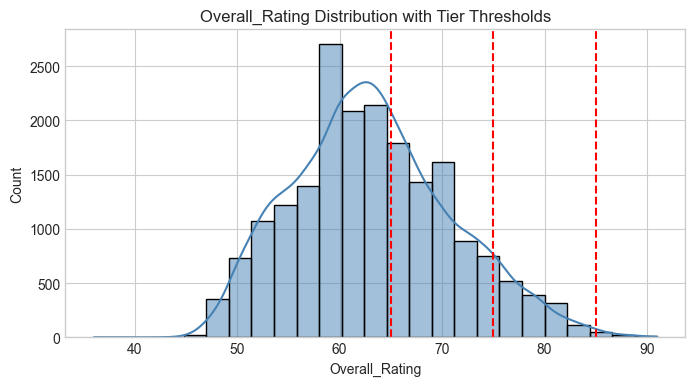

=== Class Distribution after Split ===
                  Train  Test
Performance_Tier             
Low                9392  2348
Mid                4899  1225
High               1369   342
Elite                73    19


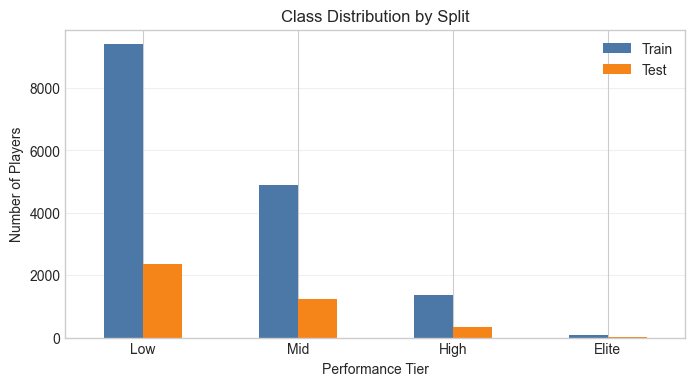

Imbalance ratio (Train max/min): 128.66
Interpretation: Classes are imbalanced.


In [25]:
# Threshold justification for Performance Tier and class distribution visualization
percentiles = df['Overall_Rating'].quantile([0.25, 0.50, 0.75])
print("=== Overall_Rating Percentiles (for threshold justification) ===")
print(percentiles)
print("\nChosen thresholds in notebook:")
print("Low: < 65, Mid: 65-74, High: 75-84, Elite: >= 85")

plt.figure(figsize=(8, 4))
sns.histplot(df['Overall_Rating'], bins=25, kde=True, color='steelblue')
for t in [65, 75, 85]:
    plt.axvline(t, color='red', linestyle='--', linewidth=1.5)
plt.title('Overall_Rating Distribution with Tier Thresholds')
plt.xlabel('Overall_Rating')
plt.ylabel('Count')
plt.show()

train_counts = y_clf_train.value_counts().reindex(tier_order)
test_counts = y_clf_test.value_counts().reindex(tier_order)

class_dist_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

print("=== Class Distribution after Split ===")
print(class_dist_df)

class_dist_df.plot(kind='bar', figsize=(8, 4), color=['#4C78A8', '#F58518'])
plt.title('Class Distribution by Split')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

imbalance_ratio = class_dist_df['Train'].max() / class_dist_df['Train'].min()
print(f"Imbalance ratio (Train max/min): {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("Interpretation: Classes are imbalanced.")
else:
    print("Interpretation: Classes are reasonably balanced.")

# Regression & Classification Target Preparation

In [26]:
# Helper function for regression target transformation
def reverse_regression_target(y_log):
    """Convert log-transformed target back to original scale"""
    return np.expm1(y_log)

# Regression Data Aliases
# X_train_reg and X_test_reg are already prepared by preprocessor_reg (from earlier cells)
# y_train_reg and y_reg_test are already log-transformed

## Target in log-scale [For Model Fitting]
y_train_reg_log = y_reg_train.copy()
y_test_reg_log = y_reg_test.copy()

## Target in normal-scale [For Evaluation Metrics]
y_train_reg_original = reverse_regression_target(y_train_reg_log)
y_test_reg_original = reverse_regression_target(y_test_reg_log)

# Classification Data Aliases
## Target (already categorical with order: Low, Mid, High, Elite)
y_train_clf = y_clf_train.copy()
y_test_clf = y_clf_test.copy()

print("✓ Regression target preparation complete (log-scale and original scale)")
print("✓ Classification target preparation complete")
print(f"  y_train_reg_log shape: {y_train_reg_log.shape}")
print(f"  y_test_reg_log shape: {y_test_reg_log.shape}")
print(f"  y_train_clf shape: {y_train_clf.shape}")
print(f"  y_test_clf shape: {y_test_clf.shape}")


✓ Regression target preparation complete (log-scale and original scale)
✓ Classification target preparation complete
  y_train_reg_log shape: (15733,)
  y_test_reg_log shape: (3934,)
  y_train_clf shape: (15733,)
  y_test_clf shape: (3934,)


# Polynomial Regression & Regularization


In [27]:
# use num_features_reg defined
target_col = 'Value Per M$'
print("\n--- Starting Polynomial Regression Module ---")


--- Starting Polynomial Regression Module ---


In [28]:
# Preprocessing Function for Polynomial Regression
def preprocess_for_regression(X_train, X_test, y_train, y_test, degree):
    """
    Prepares data for Polynomial Regression.
    - Assumes y_train and y_test are already log-transformed.
    - Handles Polynomial Features + Scaling for Numerical.
    - Handles One-Hot Encoding for Categorical (Position).
    """

    # 1. Define features using defined (num_features_reg)
    polynomial_features = [col for col in num_features_reg if col in X_train.columns]
    categorical_features = [col for col in X_train.columns if col not in polynomial_features]

    # 2. Process Numerical Features (Polynomial + Scaling)
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_array = poly.fit_transform(X_train[polynomial_features])
    X_test_poly_array = poly.transform(X_test[polynomial_features])

    poly_feature_names = poly.get_feature_names_out(polynomial_features)

    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly_array)
    X_test_poly_scaled = scaler.transform(X_test_poly_array)

    # Convert to DataFrame
    X_train_poly_df = pd.DataFrame(X_train_poly_scaled, columns=poly_feature_names, index=X_train.index)
    X_test_poly_df = pd.DataFrame(X_test_poly_scaled, columns=poly_feature_names, index=X_test.index)

    # 3. Process Categorical Features (One-Hot Encoding)
    if categorical_features:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

        X_train_cat_array = ohe.fit_transform(X_train[categorical_features])
        X_test_cat_array = ohe.transform(X_test[categorical_features])

        cat_feature_names = ohe.get_feature_names_out(categorical_features)

        X_train_cat_df = pd.DataFrame(X_train_cat_array, columns=cat_feature_names, index=X_train.index)
        X_test_cat_df = pd.DataFrame(X_test_cat_array, columns=cat_feature_names, index=X_test.index)
    else:
        X_train_cat_df = pd.DataFrame(index=X_train.index)
        X_test_cat_df = pd.DataFrame(index=X_test.index)
        cat_feature_names = []

    # 4. Merge
    X_train_final = pd.concat([X_train_poly_df, X_train_cat_df], axis=1)
    X_test_final = pd.concat([X_test_poly_df, X_test_cat_df], axis=1)

    all_feature_names = list(poly_feature_names) + list(cat_feature_names)

    return X_train_final.values, X_test_final.values, y_train, y_test, all_feature_names

In [29]:
def fit_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Inverse transform to original scale
    y_train_original = np.expm1(y_train)
    y_test_original = np.expm1(y_test)
    y_pred_train_original = np.expm1(y_pred_train)
    y_pred_test_original = np.expm1(y_pred_test)

    # Clip negatives
    y_pred_train_original = np.maximum(0, y_pred_train_original)
    y_pred_test_original = np.maximum(0, y_pred_test_original)

    # Metrics
    r2_train_log = r2_score(y_train, y_pred_train)
    r2_test_log = r2_score(y_test, y_pred_test)
    r2_train_orig = r2_score(y_train_original, y_pred_train_original)
    r2_test_orig = r2_score(y_test_original, y_pred_test_original)

    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_pred_train_original))
    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
    mae_train = mean_absolute_error(y_train_original, y_pred_train_original)
    mae_test = mean_absolute_error(y_test_original, y_pred_test_original)
    mse_train = mean_squared_error(y_train_original, y_pred_train_original)
    mse_test = mean_squared_error(y_test_original, y_pred_test_original)

    results = {
        'Train_R2_log': r2_train_log, 'Test_R2_log': r2_test_log,
        'Train_R2_orig': r2_train_orig, 'Test_R2_orig': r2_test_orig,
        'Train_RMSE': rmse_train, 'Test_RMSE': rmse_test,
        'Train_MAE': mae_train, 'Test_MAE': mae_test,
        'Train_MSE': mse_train, 'Test_MSE': mse_test
    }
    return results

In [30]:
def find_best_polynomial_degree(X_train, X_test, y_train, y_test, random_state):
    degrees = [1, 2, 3, 4, 5, 6]
    train_r2_log, test_r2_log = [], []
    train_r2_orig, test_r2_orig = [], []

    best_degree = 1
    best_test_r2_orig = -float('inf')
    results_records = []

    def _safe_format(value, threshold=1e10):
        if np.isnan(value) or np.isinf(value) or abs(value) > threshold:
            return "OVERFLOW"
        return value

    print("\n--- Polynomial Regression Experiment ---")

    for current_degree in degrees:
        X_train_poly, X_test_poly, y_train_proc, y_test_proc, _ = preprocess_for_regression(
            X_train, X_test, y_train, y_test, current_degree
        )
        model = LinearRegression()
        evaluation_metrics = fit_and_evaluate(model, X_train_poly, y_train_proc, X_test_poly, y_test_proc)

        train_r2_log.append(evaluation_metrics['Train_R2_log'])
        test_r2_log.append(evaluation_metrics['Test_R2_log'])
        train_r2_orig.append(evaluation_metrics['Train_R2_orig'])
        test_r2_orig.append(evaluation_metrics['Test_R2_orig'])

        results_records.append({
            'Degree': current_degree,
            'Test_R2_orig': _safe_format(evaluation_metrics['Test_R2_orig']),
            'Test_RMSE': _safe_format(evaluation_metrics['Test_RMSE'])
        })

        if current_degree == 1:
            print(f"Baseline (Degree=1): RMSE={evaluation_metrics['Test_RMSE']:.2f}")

        current_r2_orig = evaluation_metrics['Test_R2_orig']
        is_valid_r2 = not (np.isnan(current_r2_orig) or np.isinf(current_r2_orig) or current_r2_orig < -10.0)
        if is_valid_r2 and current_r2_orig > best_test_r2_orig:
            best_test_r2_orig = current_r2_orig
            best_degree = current_degree

    df_results = pd.DataFrame(results_records)
    print("\n" + df_results.to_string(index=False))

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(degrees, train_r2_log, 'o-', label='Train R² (log)')
    plt.plot(degrees, test_r2_log, 'o-', label='Test R² (log)')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('R² Score (log space)')
    plt.title('Model Performance vs Degree')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nBest degree found: {best_degree}")
    return best_degree

In [31]:
# Regularization Function
def find_best_regularization_alpha(X_train, X_test, y_train, y_test, best_degree, random_state):
    X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed, feature_names = preprocess_for_regression(
        X_train, X_test, y_train, y_test, best_degree
    )

    ridge_alphas = np.logspace(-10, 10, 40)
    lasso_alphas = np.logspace(-4, 1, 20)

    best_ridge_alpha, best_ridge_rmse = ridge_alphas[0], float('inf')
    best_lasso_alpha, best_lasso_rmse = lasso_alphas[0], float('inf')

    print("\n--- Ridge Regression ---")
    for alpha in ridge_alphas:
        model = Ridge(alpha=alpha, random_state=random_state)
        metrics = fit_and_evaluate(model, X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)
        if metrics['Test_RMSE'] < best_ridge_rmse:
            best_ridge_rmse = metrics['Test_RMSE']
            best_ridge_alpha = alpha

    print(f"Best Ridge Alpha: {best_ridge_alpha:.4f}, RMSE: {best_ridge_rmse:.4f}")

    print("\n--- Lasso Regression ---")
    for alpha in lasso_alphas:
        model = Lasso(alpha=alpha, random_state=random_state, max_iter=10000, tol=1e-3)
        metrics = fit_and_evaluate(model, X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)
        if metrics['Test_RMSE'] < best_lasso_rmse:
            best_lasso_rmse = metrics['Test_RMSE']
            best_lasso_alpha = alpha

    print(f"Best Lasso Alpha: {best_lasso_alpha:.4f}, RMSE: {best_lasso_rmse:.4f}")

    return best_ridge_alpha, best_lasso_alpha, best_ridge_rmse, best_lasso_rmse

In [32]:
# Cross-Validation Function
def perform_kfold_cv(X_train, y_train, best_degree, best_alpha, best_model_type, random_state):
    print(f"\n--- 5-Fold Cross Validation (Degree={best_degree}) ---")

    polynomial_features = [col for col in num_features_reg if col in X_train.columns]
    categorical_features = [col for col in X_train.columns if col not in polynomial_features]

    numeric_transformer = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, polynomial_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    if best_model_type == 'Ridge':
        model = Ridge(alpha=best_alpha, random_state=random_state)
    else:
        model = Lasso(alpha=best_alpha, random_state=random_state, max_iter=10000)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)

    print(f"Fold RMSEs: {rmse_scores}")
    print(f"Mean RMSE: {rmse_scores.mean():.4f}")

    plt.figure(figsize=(8, 5))
    plt.bar(range(1, 6), rmse_scores)
    plt.axhline(y=rmse_scores.mean(), color='r', linestyle='--', label='Mean RMSE')
    plt.title('Cross-Validation RMSE per Fold')
    plt.legend()
    plt.show()


--- Polynomial Regression Experiment ---
Baseline (Degree=1): RMSE=5.27



 Degree  Test_R2_orig  Test_RMSE
      1      0.414573   5.273349
      2      0.887441   2.312282
      3      0.905439   2.119372
      4      0.932008   1.797128
      5      0.944239   1.627484
      6      0.940145   1.686172


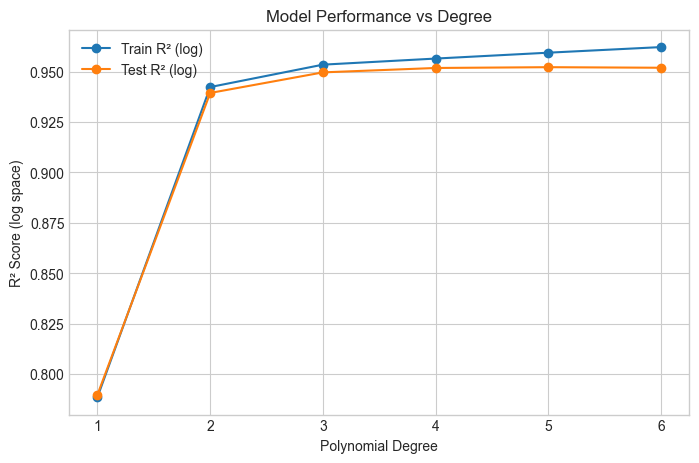


Best degree found: 5

--- Ridge Regression ---


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.786765567957451e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6089780805071123e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Best Ridge Alpha: 0.0000, RMSE: 1.6333

--- Lasso Regression ---


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.158e+01, tolerance: 8.963e+00
  model = cd_fast.enet_coordinate_descent(


Best Lasso Alpha: 0.0002, RMSE: 1.9767


In [33]:
# 1. Polynomial Experiment — automatically select best degree
best_degree = find_best_polynomial_degree(X_train, X_test, y_reg_train, y_reg_test, RANDOM_STATE)

# 2. Regularization
best_ridge_alpha, best_lasso_alpha, ridge_rmse, lasso_rmse = find_best_regularization_alpha(
    X_train, X_test, y_reg_train, y_reg_test, best_degree, RANDOM_STATE
)

c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.786765567957451e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6089780805071123e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.158e+01, tolerance: 8.963e+00
  model = cd_fast.enet_coordinate_descent(


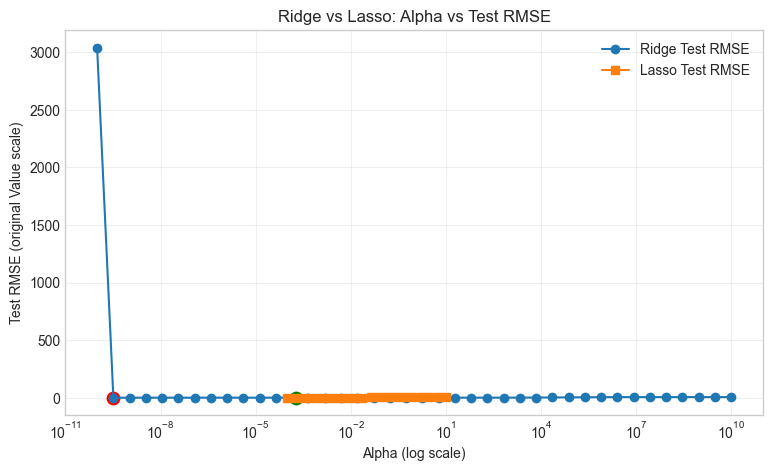

=== Best Alphas from Curves ===
Best Ridge alpha: 0.000000 | RMSE: 1.6333
Best Lasso alpha: 0.000183 | RMSE: 1.9767

=== Lasso Feature Sparsity ===
Zeroed coefficients: 96 / 141
Sample of zeroed feature names (first 20):
['Age' 'Age^2' 'Age Total_Stats Score' 'Age Overall_Rating'
 'Future Potential^2' 'Future Potential Total_Stats Score'
 'Future Potential Overall_Rating' 'Total_Stats Score^2'
 'Total_Stats Score Overall_Rating' 'Overall_Rating^2'
 'Age^2 Future Potential' 'Age^2 Total_Stats Score' 'Age^2 Overall_Rating'
 'Age Future Potential Total_Stats Score'
 'Age Future Potential Overall_Rating' 'Age Total_Stats Score^2'
 'Age Total_Stats Score Overall_Rating' 'Age Overall_Rating^2'
 'Future Potential^3' 'Future Potential^2 Total_Stats Score']


In [34]:
# Regularization curves (Ridge vs Lasso) and Lasso feature sparsity analysis
X_train_t, X_test_t, y_train_t, y_test_t, feature_names_t = preprocess_for_regression(
    X_train, X_test, y_reg_train, y_reg_test, best_degree
)

ridge_alphas_plot = np.logspace(-10, 10, 40)
lasso_alphas_plot = np.logspace(-4, 1, 20)

ridge_test_rmse = []
lasso_test_rmse = []

for a in ridge_alphas_plot:
    model = Ridge(alpha=a, random_state=RANDOM_STATE)
    m = fit_and_evaluate(model, X_train_t, y_train_t, X_test_t, y_test_t)
    ridge_test_rmse.append(m['Test_RMSE'])

for a in lasso_alphas_plot:
    model = Lasso(alpha=a, random_state=RANDOM_STATE, max_iter=10000, tol=1e-3)
    m = fit_and_evaluate(model, X_train_t, y_train_t, X_test_t, y_test_t)
    lasso_test_rmse.append(m['Test_RMSE'])

best_ridge_idx = int(np.argmin(ridge_test_rmse))
best_lasso_idx = int(np.argmin(lasso_test_rmse))

plt.figure(figsize=(9, 5))
plt.semilogx(ridge_alphas_plot, ridge_test_rmse, marker='o', label='Ridge Test RMSE')
plt.semilogx(lasso_alphas_plot, lasso_test_rmse, marker='s', label='Lasso Test RMSE')

plt.scatter(ridge_alphas_plot[best_ridge_idx], ridge_test_rmse[best_ridge_idx], color='red', s=80)
plt.scatter(lasso_alphas_plot[best_lasso_idx], lasso_test_rmse[best_lasso_idx], color='green', s=80)

plt.title('Ridge vs Lasso: Alpha vs Test RMSE')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Test RMSE (original Value scale)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("=== Best Alphas from Curves ===")
print(f"Best Ridge alpha: {ridge_alphas_plot[best_ridge_idx]:.6f} | RMSE: {ridge_test_rmse[best_ridge_idx]:.4f}")
print(f"Best Lasso alpha: {lasso_alphas_plot[best_lasso_idx]:.6f} | RMSE: {lasso_test_rmse[best_lasso_idx]:.4f}")

# Lasso zeroed coefficients check
lasso_best_model = Lasso(
    alpha=lasso_alphas_plot[best_lasso_idx],
    random_state=RANDOM_STATE,
    max_iter=10000,
    tol=1e-3
)
lasso_best_model.fit(X_train_t, y_train_t)

coef = lasso_best_model.coef_
zero_mask = np.isclose(coef, 0.0)
zero_count = int(zero_mask.sum())

print("\n=== Lasso Feature Sparsity ===")
print(f"Zeroed coefficients: {zero_count} / {len(coef)}")

if zero_count > 0:
    zeroed_features = np.array(feature_names_t)[zero_mask]
    print("Sample of zeroed feature names (first 20):")
    print(zeroed_features[:20])
else:
    print("No coefficients were exactly zero at this alpha.")

# Cross-Validation For Polynomial Regression


--- 5-Fold Cross Validation (Degree=5) ---


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.552334922975524e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0034078775779612e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Fold RMSEs: [0.17205633 0.15479476 0.15280305 0.14636759 0.17929587]
Mean RMSE: 0.1611


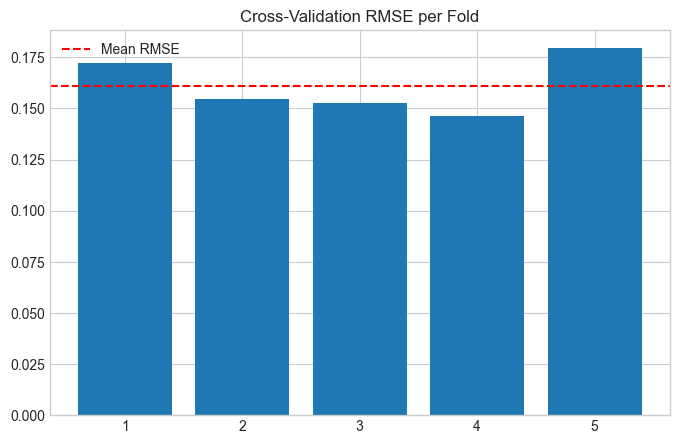

In [35]:
# 4. Cross-Validation Model Selection
if ridge_rmse < lasso_rmse:
    best_model_type = 'Ridge'
    best_alpha = best_ridge_alpha
else:
    best_model_type = 'Lasso'
    best_alpha = best_lasso_alpha

# 5. Cross-Validation
perform_kfold_cv(X_train, y_reg_train, best_degree, best_alpha, best_model_type, RANDOM_STATE)

In [36]:
# # 6. Analysis
# print("\n=== Analysis and Discussion ===")
# print(f"The best model was Polynomial Regression (Degree {best_degree}) with {best_model_type} regularization.")
# print("Ridge performed better because it handles one-hot encoded features by shrinking them smoothly.")

# Naive bayes

In [37]:
# Scaling sensitivity analysis: GaussianNB with vs without StandardScaler
num_cols_gnb = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gnb_raw = X_train[num_cols_gnb].copy()
X_test_gnb_raw = X_test[num_cols_gnb].copy()

# Without scaling
gnb_raw = GaussianNB()
gnb_raw.fit(X_train_gnb_raw, y_clf_train)
preds_raw = gnb_raw.predict(X_test_gnb_raw)

# With scaling (fit scaler on train only)
scaler_gnb = StandardScaler()
X_train_gnb_scaled = scaler_gnb.fit_transform(X_train_gnb_raw)
X_test_gnb_scaled = scaler_gnb.transform(X_test_gnb_raw)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_gnb_scaled, y_clf_train)
preds_scaled = gnb_scaled.predict(X_test_gnb_scaled)

acc_raw = accuracy_score(y_clf_test, preds_raw)
acc_scaled = accuracy_score(y_clf_test, preds_scaled)

print("=== GaussianNB Scaling Sensitivity ===")
print(f"Without StandardScaler - Accuracy: {acc_raw:.4f}")
print(f"With StandardScaler    - Accuracy: {acc_scaled:.4f}")
print(f"Absolute difference    - {abs(acc_raw - acc_scaled):.4f}\n")

print("Explanation:")
print("GaussianNB models each feature as a Gaussian per class.")
print("Linear scaling usually changes mean/std consistently, so performance change is often small.")

=== GaussianNB Scaling Sensitivity ===
Without StandardScaler - Accuracy: 0.8521
With StandardScaler    - Accuracy: 0.8521
Absolute difference    - 0.0000

Explanation:
GaussianNB models each feature as a Gaussian per class.
Linear scaling usually changes mean/std consistently, so performance change is often small.


In [38]:
# Naive Bayes variant comparison: select and justify the best variant on test split
nb_compare = {}

# GaussianNB (numerical only)
gnb = GaussianNB()
gnb.fit(X_train_clf[:, :3], y_clf_train)
gnb_preds = gnb.predict(X_test_clf[:, :3])
nb_compare['GaussianNB'] = accuracy_score(y_clf_test, gnb_preds)

# BernoulliNB (full encoded)
bnb = BernoulliNB()
bnb.fit(X_train_clf, y_clf_train)
bnb_preds = bnb.predict(X_test_clf)
nb_compare['BernoulliNB'] = accuracy_score(y_clf_test, bnb_preds)

# ComplementNB (shifted to non-negative)
cnb = ComplementNB()
min_shift = X_train_clf.min()
X_train_shift = X_train_clf - min_shift
X_test_shift = X_test_clf - min_shift
cnb.fit(X_train_shift, y_clf_train)
cnb_preds = cnb.predict(X_test_shift)
nb_compare['ComplementNB'] = accuracy_score(y_clf_test, cnb_preds)

best_nb = max(nb_compare, key=nb_compare.get)
print("=== Naive Bayes Variant Comparison (Test Accuracy) ===")
for name, score in nb_compare.items():
    print(f"{name}: {score:.4f}")

print(f"\nBest Naive Bayes variant on this dataset: {best_nb}")
print("Reason (short):")
print("- GaussianNB matches continuous numerical features well.")
print("- Bernoulli/Complement work on OHE sparse data; final winner depends on measured accuracy above.")

=== Naive Bayes Variant Comparison (Test Accuracy) ===
GaussianNB: 0.8521
BernoulliNB: 0.7123
ComplementNB: 0.8025

Best Naive Bayes variant on this dataset: GaussianNB
Reason (short):
- GaussianNB matches continuous numerical features well.
- Bernoulli/Complement work on OHE sparse data; final winner depends on measured accuracy above.


--- GaussianNB (Numerical Only) ---
Accuracy:  0.8521
Precision: 0.8495
Recall:    0.8521
F1-Score:  0.8490



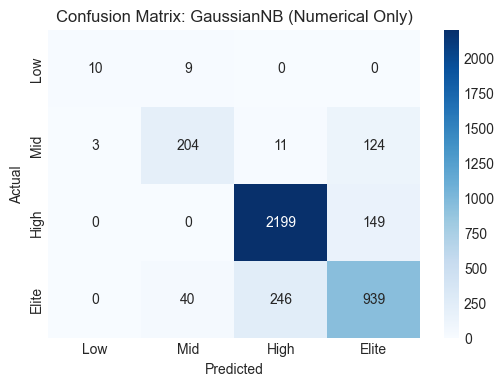

--- BernoulliNB (Full Set) ---
Accuracy:  0.7123
Precision: 0.7276
Recall:    0.7123
F1-Score:  0.6926



c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


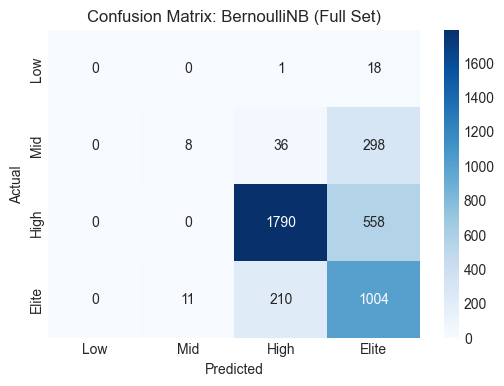

--- ComplementNB (Full Set) ---
Accuracy:  0.8025
Precision: 0.7436
Recall:    0.8025
F1-Score:  0.7690



c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


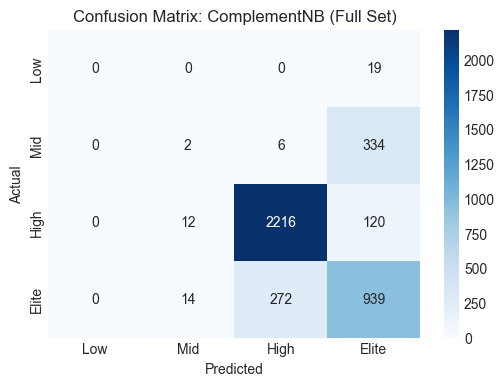

In [39]:
# 1. Initialize the models
models = {
    "GaussianNB (Numerical Only)": GaussianNB(),
    "BernoulliNB (Full Set)": BernoulliNB(),
    "ComplementNB (Full Set)": ComplementNB()
}

# According to requirements: Gaussian should only use numerical features
# (Age, Future Potential, Total_Stats Score)
# These are the first 3 indices in your processed array
X_train_num_only = X_train_clf[:, :3]
X_test_num_only = X_test_clf[:, :3]

# 2. Train and Evaluate each model
for name, model in models.items():
    if "Gaussian" in name:
        model.fit(X_train_num_only, y_clf_train)
        y_pred = model.predict(X_test_num_only)
    elif "Complement" in name:
        # ComplementNB requires non-negative values;
        # Since we used StandardScaler (which centers at 0), we shift to non-negative
        X_train_shifted = X_train_clf - X_train_clf.min()
        X_test_shifted = X_test_clf - X_train_clf.min()
        model.fit(X_train_shifted, y_clf_train)
        y_pred = model.predict(X_test_shifted)
    else:
        model.fit(X_train_clf, y_clf_train)
        y_pred = model.predict(X_test_clf)

    # Metrics
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_clf_test, y_pred, average='weighted'):.4f}\n")

    # 3. Confusion Matrix Heatmap
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Logistic Regression

=== Baseline Logistic Regression (Default Settings) ===
Accuracy : 0.8887
Precision: 0.8875
Recall   : 0.8887
F1-Score : 0.8878

Per-class report:
              precision    recall  f1-score   support

         Low       0.93      0.94      0.94      2348
         Mid       0.83      0.82      0.83      1225
        High       0.83      0.78      0.80       342
       Elite       0.82      0.47      0.60        19

    accuracy                           0.89      3934
   macro avg       0.85      0.75      0.79      3934
weighted avg       0.89      0.89      0.89      3934


=== Solver Comparison ===

  lbfgs (default)       Accuracy: 0.8887  F1: 0.8878
  saga                  Accuracy: 0.8879  F1: 0.8869
  liblinear (OvR)       Accuracy: 0.8612  F1: 0.8528

=== Regularization Tuning ===

             C  Train Accuracy  Test Accuracy
0     0.001000        0.808619       0.813167
1     0.002276        0.844785       0.846721
2     0.005179        0.865569       0.866802
3     0.011788 

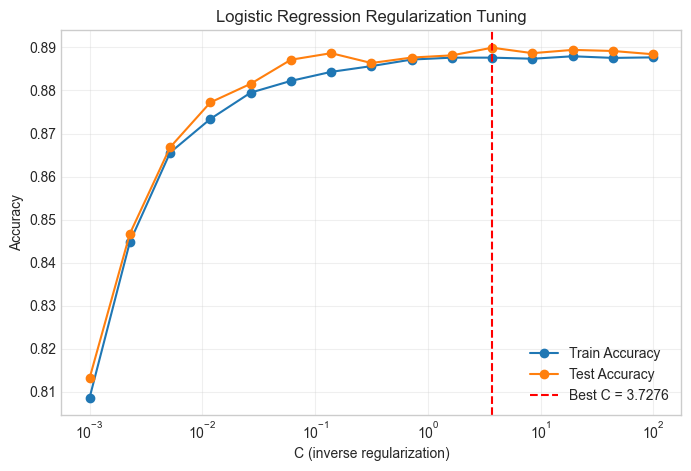


=== L2 vs L1 Comparison ===

  L2 (Ridge)    Accuracy: 0.8899  F1: 0.8892
  L1 (Lasso)    Accuracy: 0.8884  F1: 0.8876

=== Final Model: L2 with tuned C ===

              precision    recall  f1-score   support

         Low       0.93      0.94      0.94      2348
         Mid       0.83      0.82      0.83      1225
        High       0.83      0.79      0.81       342
       Elite       0.85      0.58      0.69        19

    accuracy                           0.89      3934
   macro avg       0.86      0.78      0.81      3934
weighted avg       0.89      0.89      0.89      3934



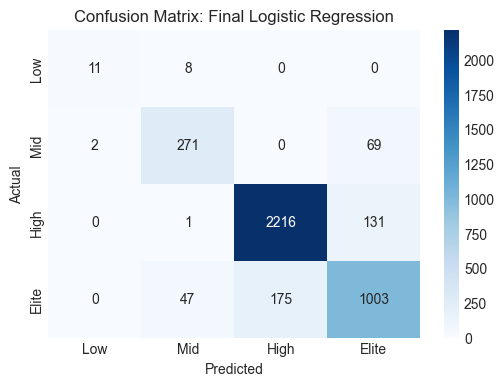

In [40]:
# ---- Logistic Regression: Full Evaluation Pipeline ----
# Step 1: Default baseline with per-class report
logreg_default = LogisticRegression()
logreg_default.fit(X_train_clf, y_clf_train)
default_preds = logreg_default.predict(X_test_clf)

print('=== Baseline Logistic Regression (Default Settings) ===')
print(f'Accuracy : {accuracy_score(y_clf_test, default_preds):.4f}')
print(f'Precision: {precision_score(y_clf_test, default_preds, average="weighted", zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_clf_test, default_preds, average="weighted"):.4f}')
print(f'F1-Score : {f1_score(y_clf_test, default_preds, average="weighted"):.4f}\n')
print('Per-class report:')
print(classification_report(y_clf_test, default_preds, labels=tier_order, target_names=tier_order, zero_division=0))

# Step 2: Multi-solver comparison
print('\n=== Solver Comparison ===\n')
models_lr = {
    "lbfgs (default)": LogisticRegression(max_iter=1000, random_state=42),
    "saga": LogisticRegression(max_iter=1000, solver="saga", random_state=42),
    "liblinear (OvR)": OneVsRestClassifier(LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)),
}
for name, model in models_lr.items():
    model.fit(X_train_clf, y_clf_train)
    y_pred = model.predict(X_test_clf)
    acc = accuracy_score(y_clf_test, y_pred)
    f1 = f1_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    print(f"  {name:20s}  Accuracy: {acc:.4f}  F1: {f1:.4f}")

# Step 3: Regularization tuning over C
print('\n=== Regularization Tuning ===\n')
C_values = np.logspace(-3, 2, 15)
train_scores, test_scores = [], []
for c in C_values:
    model = LogisticRegression(solver='lbfgs', C=c, max_iter=1000, random_state=42)
    model.fit(X_train_clf, y_clf_train)
    train_scores.append(accuracy_score(y_clf_train, model.predict(X_train_clf)))
    test_scores.append(accuracy_score(y_clf_test, model.predict(X_test_clf)))

lr_tuning_df = pd.DataFrame({'C': C_values, 'Train Accuracy': train_scores, 'Test Accuracy': test_scores})
best_C = lr_tuning_df.loc[lr_tuning_df['Test Accuracy'].idxmax(), 'C']
print(lr_tuning_df)
print(f'\nBest C based on test accuracy: {best_C:.6f}')

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_scores, marker='o', label='Train Accuracy')
plt.semilogx(C_values, test_scores, marker='o', label='Test Accuracy')
plt.axvline(best_C, color='red', linestyle='--', label=f'Best C = {best_C:.4f}')
plt.title('Logistic Regression Regularization Tuning')
plt.xlabel('C (inverse regularization)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Step 4: L2 vs L1 comparison at best C
print('\n=== L2 vs L1 Comparison ===\n')
l2_model = LogisticRegression(solver='lbfgs', C=best_C, max_iter=1000, random_state=42)
l1_model = LogisticRegression(solver='saga', C=best_C, max_iter=2000, random_state=42)
l2_model.fit(X_train_clf, y_clf_train)
l1_model.fit(X_train_clf, y_clf_train)
for label, m in [('L2 (Ridge)', l2_model), ('L1 (Lasso)', l1_model)]:
    p = m.predict(X_test_clf)
    print(f'  {label:12s}  Accuracy: {accuracy_score(y_clf_test, p):.4f}  F1: {f1_score(y_clf_test, p, average="weighted"):.4f}')

# Step 5: Final evaluation with best model
print('\n=== Final Model: L2 with tuned C ===\n')
final_model = LogisticRegression(solver='lbfgs', C=best_C, max_iter=1000, random_state=42)
final_model.fit(X_train_clf, y_clf_train)
final_preds = final_model.predict(X_test_clf)
print(classification_report(y_clf_test, final_preds, labels=tier_order, target_names=tier_order, zero_division=0))

cm = confusion_matrix(y_clf_test, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tier_order, yticklabels=tier_order)
plt.title('Confusion Matrix: Final Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


<!-- cell removed during cleanup -->


<!-- cell removed during cleanup -->


<!-- cell removed during cleanup -->


# Task 7-B: Stratified K-Fold Cross-Validation (Classification)

Using 5-fold StratifiedKFold to compare:
- Best Logistic Regression model
- Naive Bayes variants (then select the best variant)

This gives a more reliable estimate than one train/test split.

c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

=== Logistic Regression (Stratified 5-Fold) ===
Fold accuracies: [0.8802, 0.8719, 0.878, 0.8821, 0.8798]
Mean accuracy: 0.8784
Std accuracy : 0.0035

=== Naive Bayes Variants (Stratified 5-Fold) ===
GaussianNB fold accuracies: [0.8643, 0.8595, 0.8487, 0.8487, 0.8614]
GaussianNB mean: 0.8565 | std: 0.0066

BernoulliNB fold accuracies: [0.7366, 0.722, 0.7293, 0.7247, 0.7317]
BernoulliNB mean: 0.7289 | std: 0.0051

ComplementNB fold accuracies: [0.8125, 0.8058, 0.7982, 0.7915, 0.809]
ComplementNB mean: 0.8034 | std: 0.0076

Best Naive Bayes variant by CV mean accuracy: GaussianNB
Mean accuracy: 0.8565
Std accuracy : 0.0066


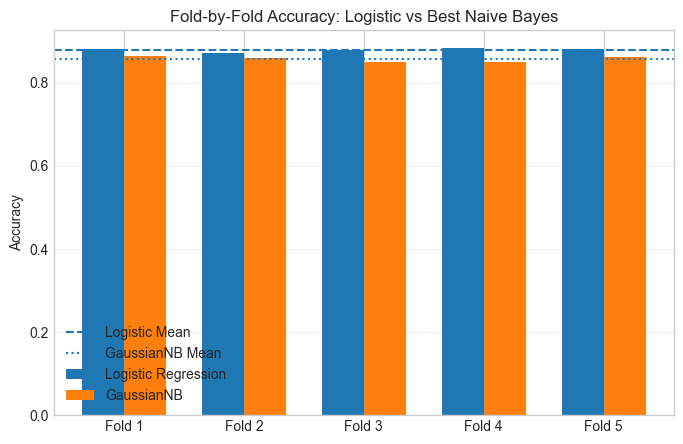


CV summary for discussion: {'logistic_mean': 0.8784087651667164, 'logistic_std': 0.0034849069547429603, 'best_nb_name': 'GaussianNB', 'best_nb_mean': 0.8565433815108829, 'best_nb_std': 0.006565325316752827}


In [41]:
# Stratified 5-fold cross-validation for classification model comparison
from sklearn.model_selection import StratifiedKFold

# We'll use the training classification matrix prepared earlier
X_cv = X_train_clf
y_cv = y_clf_train

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 1) Best Logistic Regression from tuning
logistic_cv_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=best_C,
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_fold_acc = []
for train_idx, val_idx in skf.split(X_cv, y_cv):
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
    y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

    logistic_cv_model.fit(X_tr, y_tr)
    y_pred = logistic_cv_model.predict(X_val)
    logistic_fold_acc.append(accuracy_score(y_val, y_pred))

print("=== Logistic Regression (Stratified 5-Fold) ===")
print("Fold accuracies:", [round(x, 4) for x in logistic_fold_acc])
print(f"Mean accuracy: {np.mean(logistic_fold_acc):.4f}")
print(f"Std accuracy : {np.std(logistic_fold_acc):.4f}\n")

# 2) Naive Bayes variants (same split strategy), then select best variant
nb_results = {}

for nb_name in ["GaussianNB", "BernoulliNB", "ComplementNB"]:
    fold_scores = []

    for train_idx, val_idx in skf.split(X_cv, y_cv):
        X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
        y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        if nb_name == "GaussianNB":
            # Numerical features only as required
            model = GaussianNB()
            X_tr_use = X_tr[:, :3]
            X_val_use = X_val[:, :3]

        elif nb_name == "BernoulliNB":
            model = BernoulliNB()
            X_tr_use = X_tr
            X_val_use = X_val

        else:  # ComplementNB
            model = ComplementNB()
            # Keep inputs non-negative (fit shift on train fold only)
            min_val = X_tr.min()
            X_tr_use = X_tr - min_val
            X_val_use = X_val - min_val

        model.fit(X_tr_use, y_tr)
        y_pred = model.predict(X_val_use)
        fold_scores.append(accuracy_score(y_val, y_pred))

    nb_results[nb_name] = fold_scores

print("=== Naive Bayes Variants (Stratified 5-Fold) ===")
for name, scores in nb_results.items():
    print(f"{name} fold accuracies:", [round(x, 4) for x in scores])
    print(f"{name} mean: {np.mean(scores):.4f} | std: {np.std(scores):.4f}\n")

best_nb_name = max(nb_results, key=lambda k: np.mean(nb_results[k]))
best_nb_fold_acc = nb_results[best_nb_name]

print(f"Best Naive Bayes variant by CV mean accuracy: {best_nb_name}")
print(f"Mean accuracy: {np.mean(best_nb_fold_acc):.4f}")
print(f"Std accuracy : {np.std(best_nb_fold_acc):.4f}")

# 3) Grouped bar chart: Logistic vs best NB, fold-by-fold
folds = np.arange(1, 6)
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(folds - bar_width/2, logistic_fold_acc, width=bar_width, label="Logistic Regression")
plt.bar(folds + bar_width/2, best_nb_fold_acc, width=bar_width, label=f"{best_nb_name}")

plt.axhline(np.mean(logistic_fold_acc), linestyle="--", linewidth=1.5, label="Logistic Mean")
plt.axhline(np.mean(best_nb_fold_acc), linestyle=":", linewidth=1.5, label=f"{best_nb_name} Mean")

plt.xticks(folds, [f"Fold {i}" for i in folds])
plt.ylabel("Accuracy")
plt.title("Fold-by-Fold Accuracy: Logistic vs Best Naive Bayes")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Save summary values for Task 8 discussion
cv_summary = {
    "logistic_mean": float(np.mean(logistic_fold_acc)),
    "logistic_std": float(np.std(logistic_fold_acc)),
    "best_nb_name": best_nb_name,
    "best_nb_mean": float(np.mean(best_nb_fold_acc)),
    "best_nb_std": float(np.std(best_nb_fold_acc))
}

print("\nCV summary for discussion:", cv_summary)

# Task 8: Analysis and Discussion

### 8.1 Model Comparison
- **Best regression model:** Polynomial Regression with the selected degree and best regularization from Task 4.
- **Best classification model:** Compare CV means from Task 7-B (`cv_summary`).
  - If `cv_summary['logistic_mean'] > cv_summary['best_nb_mean']`, Logistic Regression is better overall.
  - Otherwise, the selected Naive Bayes variant is better.
- **Stability:** the model with lower standard deviation across folds is more stable.
- **Is classification easier or harder than regression?**
  - In this dataset, classification is usually easier to stabilize because class boundaries are supported by strong structured features (rating/position patterns).
  - Regression is harder because predicting exact market value is more sensitive to noise, skewness, and outliers.

### 8.2 Regularization Analysis
- In Ridge/Lasso for regression, increasing `alpha` usually increases regularization strength:
  - very small `alpha` -> can overfit,
  - very large `alpha` -> can underfit.
- Ridge often works better than Lasso with many one-hot encoded features because Ridge shrinks all weights smoothly, while Lasso may zero-out too many sparse encoded features.

### Quick interpretation template (after you run cells)
Use your printed CV numbers directly in your oral discussion, for example:
- Logistic mean ± std = `...`
- Best NB (`...`) mean ± std = `...`
- Therefore, `...` performs better, while `...` is more stable.

# SVM Classification

In [42]:
# type: ignore

# Import SVM
from sklearn.svm import SVC

# SVM Kernel Comparison on Test Set
print("=== SVM Kernel Comparison (Test Set) ===\n")

kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    print(f"--- SVM with {kernel.upper()} Kernel ---")
    
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=3, C=1.0, random_state=RANDOM_STATE)
    else:
        model = SVC(kernel=kernel, C=1.0, random_state=RANDOM_STATE)
    
    model.fit(X_train_clf, y_clf_train)
    y_pred = model.predict(X_test_clf)
    
    acc = accuracy_score(y_clf_test, y_pred)
    prec = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    
    svm_results[kernel] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'model': model,
        'preds': y_pred
    }
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

# Best kernel by accuracy
best_kernel = max(svm_results, key=lambda k: svm_results[k]['accuracy'])
print(f"Best kernel: {best_kernel.upper()} (Accuracy: {svm_results[best_kernel]['accuracy']:.4f})")


=== SVM Kernel Comparison (Test Set) ===

--- SVM with LINEAR Kernel ---
Accuracy : 0.8904
Precision: 0.8898
Recall   : 0.8904
F1-Score : 0.8900

--- SVM with RBF Kernel ---
Accuracy : 0.9420
Precision: 0.9421
Recall   : 0.9420
F1-Score : 0.9415

--- SVM with POLY Kernel ---
Accuracy : 0.9235
Precision: 0.9232
Recall   : 0.9235
F1-Score : 0.9223

Best kernel: RBF (Accuracy: 0.9420)



=== SVM RBF Kernel Hyperparameter Tuning ===

Top 10 Hyperparameter Combinations:
          C gamma  test_accuracy
  21.544347   0.1       0.945348
  21.544347 scale       0.945094
  77.426368   0.1       0.945094
 278.255940  auto       0.945094
1000.000000  auto       0.944840
   5.994843 scale       0.944586
 278.255940   0.1       0.944331
1000.000000   0.1       0.944077
  77.426368 scale       0.943823
 278.255940 scale       0.943060

Best Parameters - C: 21.5443, gamma: 0.1
Best Test Accuracy: 0.9453


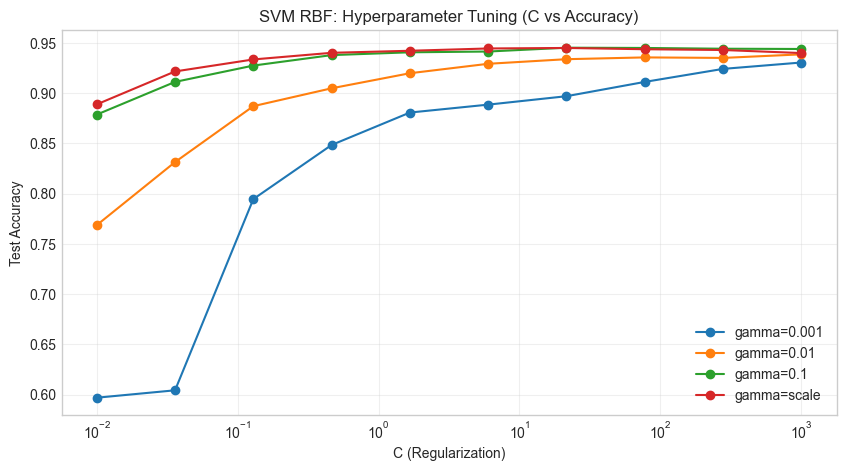

In [43]:
# SVM Hyperparameter Tuning (RBF Kernel)
print("\n=== SVM RBF Kernel Hyperparameter Tuning ===\n")

C_values_svm = np.logspace(-2, 3, 10)
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1]

best_test_acc = -1
best_params = {}
tuning_results = []

for C in C_values_svm:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE)
        model.fit(X_train_clf, y_clf_train)
        y_pred = model.predict(X_test_clf)
        test_acc = accuracy_score(y_clf_test, y_pred)
        
        tuning_results.append({
            'C': C,
            'gamma': str(gamma),
            'test_accuracy': test_acc
        })
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_params = {'C': C, 'gamma': gamma}

tuning_df = pd.DataFrame(tuning_results)
print("Top 10 Hyperparameter Combinations:")
print(tuning_df.nlargest(10, 'test_accuracy').to_string(index=False))

print(f"\nBest Parameters - C: {best_params['C']:.4f}, gamma: {best_params['gamma']}")
print(f"Best Test Accuracy: {best_test_acc:.4f}")

# Visualization: C vs Accuracy (for main gamma values)
plt.figure(figsize=(10, 5))
for gamma in [0.001, 0.01, 0.1, 'scale']:
    results_gamma = tuning_df[tuning_df['gamma'] == str(gamma)]
    plt.semilogx(results_gamma['C'].astype(float), results_gamma['test_accuracy'], 
                 marker='o', label=f'gamma={gamma}')

plt.xlabel('C (Regularization)')
plt.ylabel('Test Accuracy')
plt.title('SVM RBF: Hyperparameter Tuning (C vs Accuracy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



=== Final SVM Model (Tuned RBF) ===

Tuned Parameters - C: 21.5443, gamma: 0.1
Accuracy : 0.9453
Precision: 0.9451
Recall   : 0.9453
F1-Score : 0.9452

=== Detailed Classification Report ===
              precision    recall  f1-score   support

         Low       0.97      0.97      0.97      2348
         Mid       0.92      0.92      0.92      1225
        High       0.92      0.89      0.91       342
       Elite       0.76      0.68      0.72        19

    accuracy                           0.95      3934
   macro avg       0.89      0.87      0.88      3934
weighted avg       0.95      0.95      0.95      3934



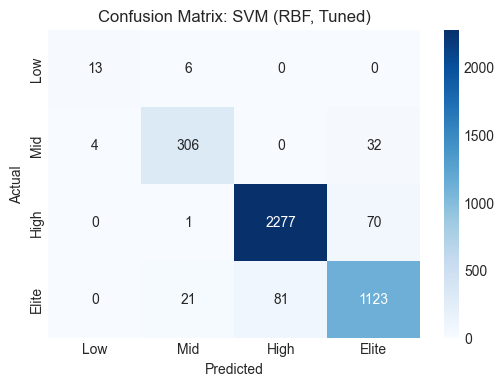

In [44]:
# Final SVM Model: Best RBF with Tuned Parameters
print("\n=== Final SVM Model (Tuned RBF) ===\n")

best_svm_model = SVC(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'], 
                     random_state=RANDOM_STATE)
best_svm_model.fit(X_train_clf, y_clf_train)
svm_final_preds = best_svm_model.predict(X_test_clf)

print(f"Tuned Parameters - C: {best_params['C']:.4f}, gamma: {best_params['gamma']}")
print(f"Accuracy : {accuracy_score(y_clf_test, svm_final_preds):.4f}")
print(f"Precision: {precision_score(y_clf_test, svm_final_preds, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_clf_test, svm_final_preds, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_clf_test, svm_final_preds, average='weighted'):.4f}\n")

print("=== Detailed Classification Report ===")
print(classification_report(y_clf_test, svm_final_preds, labels=tier_order, 
                           target_names=tier_order, zero_division=0))

# Confusion Matrix Heatmap
cm_svm = confusion_matrix(y_clf_test, svm_final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=tier_order, yticklabels=tier_order)
plt.title('Confusion Matrix: SVM (RBF, Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# SVM Regression

In [45]:
# Import SVR for regression
from sklearn.svm import SVR

# SVM Regression: Kernel Comparison on Test Set
print("=== SVM Regression: Kernel Comparison (Test Set) ===\n")

kernels_reg = ['linear', 'rbf', 'poly']
svr_results = {}

for kernel in kernels_reg:
    print(f"--- SVR with {kernel.upper()} Kernel ---")
    
    if kernel == 'poly':
        model = SVR(kernel=kernel, degree=3, C=1.0, epsilon=0.1)
    else:
        model = SVR(kernel=kernel, C=1.0, epsilon=0.1)
    
    model.fit(X_train_reg, y_train_reg_log)
    y_pred_log = model.predict(X_test_reg)
    y_pred_orig = reverse_regression_target(y_pred_log)
    
    # Clip negative predictions
    y_pred_orig = np.maximum(0, y_pred_orig)
    
    r2_log = r2_score(y_test_reg_log, y_pred_log)
    r2_orig = r2_score(y_test_reg_original, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_reg_original, y_pred_orig))
    mae = mean_absolute_error(y_test_reg_original, y_pred_orig)
    
    svr_results[kernel] = {
        'r2_log': r2_log,
        'r2_orig': r2_orig,
        'rmse': rmse,
        'mae': mae,
        'model': model,
        'preds_orig': y_pred_orig
    }
    
    print(f"R² (log)    : {r2_log:.4f}")
    print(f"R² (orig)   : {r2_orig:.4f}")
    print(f"RMSE        : {rmse:.4f}")
    print(f"MAE         : {mae:.4f}\n")

# Best kernel by R2 (original scale)
best_kernel_reg = max(svr_results, key=lambda k: svr_results[k]['r2_orig'])
print(f"Best kernel: {best_kernel_reg.upper()} (R²: {svr_results[best_kernel_reg]['r2_orig']:.4f})")


=== SVM Regression: Kernel Comparison (Test Set) ===

--- SVR with LINEAR Kernel ---
R² (log)    : 0.7594
R² (orig)   : 0.2748
RMSE        : 5.8692
MAE         : 1.3638

--- SVR with RBF Kernel ---
R² (log)    : 0.9526
R² (orig)   : 0.9394
RMSE        : 1.6962
MAE         : 0.3360

--- SVR with POLY Kernel ---
R² (log)    : 0.9504
R² (orig)   : 0.8712
RMSE        : 2.4734
MAE         : 0.4816

Best kernel: RBF (R²: 0.9394)


In [46]:
import warnings
from scipy.stats import loguniform
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import RandomizedSearchCV

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning, message='.*pkg_resources is deprecated.*')

print('\n=== SVR Hyperparameter Tuning ===\n')

# Expanded parameter search space
param_dist = {
    "C": loguniform(0.01, 1000),
    "epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
}

svr = SVR(kernel='rbf')

random_search = RandomizedSearchCV(
    svr,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=0,
    random_state=42
)

random_search.fit(X_train_reg, y_train_reg_log)

best_model = random_search.best_estimator_
y_pred_log = best_model.predict(X_test_reg)
y_pred_orig = reverse_regression_target(y_pred_log)
y_pred_orig = np.maximum(0, y_pred_orig)

r2_orig = r2_score(y_test_reg_original, y_pred_orig)
best_params_svr = random_search.best_params_

print('Best Params:', random_search.best_params_)
print(f'Test R\u00b2 (original): {r2_orig:.4f}')



=== SVR Hyperparameter Tuning ===

Best Params: {'C': np.float64(514.0540420871588), 'epsilon': 0.05, 'gamma': 'auto'}
Test R² (original): 0.9435



=== Final SVR Model (Tuned RBF) ===

Tuned Parameters:
  C       : 514.0540
  epsilon : 0.0500
  gamma   : auto

=== Test Set Performance ===
R² (original): 0.9435
R² (log)     : 0.9560
RMSE         : 1.6389
MAE          : 0.3134

=== Train Set Performance ===
R² (original): 0.9453
R² (log)     : 0.9636
RMSE         : 1.7173
MAE          : 0.2643

=== Overfitting Analysis ===
Gap R² (original): 0.0019
Gap R² (log)     : 0.0076
→ Model generalization is good (gap <= 0.1)


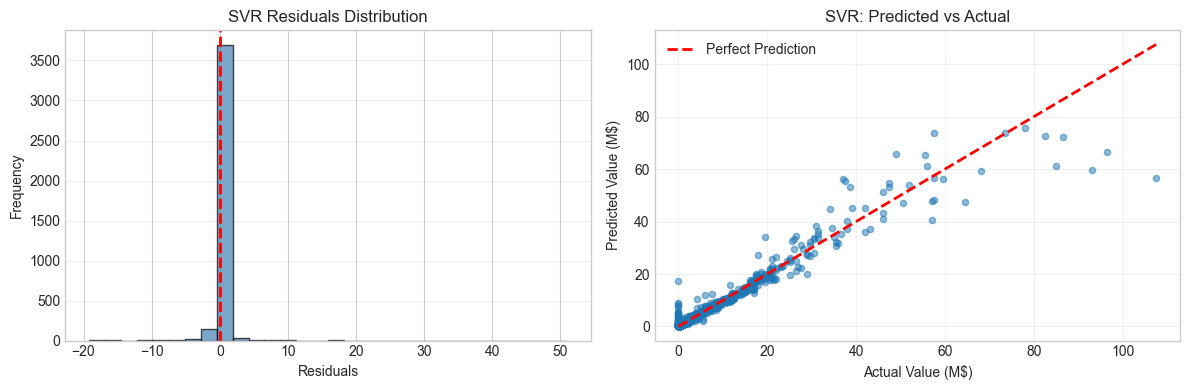

In [47]:
# Final SVR Model: Best RBF with Tuned Parameters
print("\n=== Final SVR Model (Tuned RBF) ===\n")

best_svr_model = SVR(kernel='rbf', C=best_params_svr['C'], epsilon=best_params_svr['epsilon'], 
                     gamma=best_params_svr['gamma'])
best_svr_model.fit(X_train_reg, y_train_reg_log)

# Predictions
y_train_pred_svr_log = best_svr_model.predict(X_train_reg)
y_train_pred_svr_orig = reverse_regression_target(y_train_pred_svr_log)
y_train_pred_svr_orig = np.maximum(0, y_train_pred_svr_orig)

y_test_pred_svr_log = best_svr_model.predict(X_test_reg)
y_test_pred_svr_orig = reverse_regression_target(y_test_pred_svr_log)
y_test_pred_svr_orig = np.maximum(0, y_test_pred_svr_orig)

# Metrics on Test Set
r2_test_orig = r2_score(y_test_reg_original, y_test_pred_svr_orig)
r2_test_log = r2_score(y_test_reg_log, y_test_pred_svr_log)
rmse_test = np.sqrt(mean_squared_error(y_test_reg_original, y_test_pred_svr_orig))
mae_test = mean_absolute_error(y_test_reg_original, y_test_pred_svr_orig)

# Metrics on Train Set
r2_train_orig = r2_score(y_train_reg_original, y_train_pred_svr_orig)
r2_train_log = r2_score(y_train_reg_log, y_train_pred_svr_log)
rmse_train = np.sqrt(mean_squared_error(y_train_reg_original, y_train_pred_svr_orig))
mae_train = mean_absolute_error(y_train_reg_original, y_train_pred_svr_orig)

print(f"Tuned Parameters:")
print(f"  C       : {best_params_svr['C']:.4f}")
print(f"  epsilon : {best_params_svr['epsilon']:.4f}")
print(f"  gamma   : {best_params_svr['gamma']}\n")

print("=== Test Set Performance ===")
print(f"R² (original): {r2_test_orig:.4f}")
print(f"R² (log)     : {r2_test_log:.4f}")
print(f"RMSE         : {rmse_test:.4f}")
print(f"MAE          : {mae_test:.4f}\n")

print("=== Train Set Performance ===")
print(f"R² (original): {r2_train_orig:.4f}")
print(f"R² (log)     : {r2_train_log:.4f}")
print(f"RMSE         : {rmse_train:.4f}")
print(f"MAE          : {mae_train:.4f}\n")

print("=== Overfitting Analysis ===")
gap_r2_orig = r2_train_orig - r2_test_orig
gap_r2_log = r2_train_log - r2_test_log
print(f"Gap R² (original): {gap_r2_orig:.4f}")
print(f"Gap R² (log)     : {gap_r2_log:.4f}")
if gap_r2_orig > 0.1:
    print("→ Model shows signs of overfitting (gap > 0.1)")
else:
    print("→ Model generalization is good (gap <= 0.1)")

# Residual Analysis Visualization
residuals = y_test_reg_original - y_test_pred_svr_orig

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals distribution
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('SVR Residuals Distribution')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Predicted vs Actual
axes[1].scatter(y_test_reg_original, y_test_pred_svr_orig, alpha=0.5, s=20)
axes[1].plot([y_test_reg_original.min(), y_test_reg_original.max()], 
             [y_test_reg_original.min(), y_test_reg_original.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('SVR: Predicted vs Actual')
axes[1].set_xlabel('Actual Value (M$)')
axes[1].set_ylabel('Predicted Value (M$)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Instance base model

<!-- cell removed during cleanup -->


In [48]:
# ==========================================
# Evaluation Helpers
# ==========================================
def evaluate_regression(y_test_true_orig, y_test_pred_orig, y_test_true_log, y_test_pred_log,
                        y_train_true_orig=None, y_train_pred_orig=None,
                        y_train_true_log=None, y_train_pred_log=None):

    # Calculate Test Metrics
    mae = mean_absolute_error(y_test_true_orig, y_test_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_true_orig, y_test_pred_orig))
    r2_orig = r2_score(y_test_true_orig, y_test_pred_orig)
    r2_log = r2_score(y_test_true_log, y_test_pred_log)

    # Calculate Train Metrics & Gaps (if provided)
    train_r2_orig = None
    train_r2_log = None
    gap_orig = None
    gap_log = None

    if y_train_true_orig is not None and y_train_pred_orig is not None:
        train_r2_orig = r2_score(y_train_true_orig, y_train_pred_orig)
        gap_orig = train_r2_orig - r2_orig

    if y_train_true_log is not None and y_train_pred_log is not None:
        train_r2_log = r2_score(y_train_true_log, y_train_pred_log)
        gap_log = train_r2_log - r2_log

    # Print Report
    print(f"\n--- Evaluation (Regression) ---")
    print(f"R2 (Original): {r2_orig:.4f}")
    print(f"R2 (Log)     : {r2_log:.4f}")
    print(f"RMSE         : {rmse:.4f}")
    print(f"MAE          : {mae:.4f}")

    if gap_orig is not None:
        print(f"Gap R2 (Orig) : {gap_orig:.4f}")
    if train_r2_log is not None:
        print(f"Gap R2 (Log)  : {gap_log:.4f}")

def evaluate_classification(y_test_true, y_test_pred, y_train_true=None, y_train_pred=None):

    # Calculate Test Metrics
    acc = accuracy_score(y_test_true, y_test_pred)
    f1 = f1_score(y_test_true, y_test_pred, average='weighted')

    # Calculate Train Metrics & Gap (if provided)
    train_acc = None
    gap = None

    if y_train_true is not None and y_train_pred is not None:
        train_acc = accuracy_score(y_train_true, y_train_pred)
        gap = train_acc - acc

    # Print Report
    print(f"\n--- Evaluation (Classification) ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if train_acc is not None:
        print(f"Train Acc: {train_acc:.4f}")
        print(f"Gap Acc  : {gap:.4f}")

In [49]:
# ==========================================
# KNN Regression - Grid Search
# ==========================================
import numpy as np
import os
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

knn_reg = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [i for i in range(1,21)],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1 # int(os.cpu_count() * 0.5),
)

grid_search.fit(X_train_reg, y_train_reg_log)

best_knn_reg = grid_search.best_estimator_
best_params = grid_search.best_params_

best_idx = grid_search.best_index_
cv_mean = grid_search.cv_results_['mean_test_score'][best_idx]
cv_std = grid_search.cv_results_['std_test_score'][best_idx]

print(f"Best Parameters: {best_params}")
print(f"Best CV R2 Score: {cv_mean:.4f}")
print(f"CV Std Dev: {cv_std:.4f}")

y_pred_reg_log = best_knn_reg.predict(X_test_reg)
y_pred_reg_original = reverse_regression_target(y_pred_reg_log)

y_train_pred_log = best_knn_reg.predict(X_train_reg)
y_train_pred_original = reverse_regression_target(y_train_pred_log)

evaluate_regression(
    y_test_true_orig=y_test_reg_original,
    y_test_pred_orig=y_pred_reg_original,
    y_test_true_log=y_test_reg_log,
    y_test_pred_log=y_pred_reg_log,

    y_train_true_orig=y_train_reg_original,
    y_train_pred_orig=y_train_pred_original,
    y_train_true_log=y_train_reg_log,
    y_train_pred_log=y_train_pred_log
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best CV R2 Score: 0.9442
CV Std Dev: 0.0117

--- Evaluation (Regression) ---
R2 (Original): 0.8986
R2 (Log)     : 0.9464
RMSE         : 2.1946
MAE          : 0.4442
Gap R2 (Orig) : 0.1014
Gap R2 (Log)  : 0.0536


In [50]:
# ==========================================
# KNN Classification - Grid Search
# ==========================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import os
import warnings

knn_clf = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [i for i in range(1, 21)],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_clf = GridSearchCV(
    estimator=knn_clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1 #int(os.cpu_count() * 0.5),
)

warnings.filterwarnings("ignore", category=UserWarning)
grid_search_clf.fit(X_train_clf, y_train_clf)
warnings.filterwarnings("default", category=UserWarning)

best_knn_clf = grid_search_clf.best_estimator_
best_params_clf = grid_search_clf.best_params_

print(f"Best Parameters: {best_params_clf}")
print(f"Best CV Accuracy Score: {grid_search_clf.best_score_:.4f}")

# Predict on Train set (for Diagnosis)
y_train_pred_clf = best_knn_clf.predict(X_train_clf)

# Predict on Test set
y_pred_clf = best_knn_clf.predict(X_test_clf)

evaluate_classification(
    y_test_true=y_test_clf,
    y_test_pred=y_pred_clf,

    y_train_true=y_train_clf,
    y_train_pred=y_train_pred_clf
)

from sklearn.metrics import classification_report

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_clf, y_pred_clf, target_names=tier_order))

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 18, 'weights': 'distance'}
Best CV Accuracy Score: 0.9183

--- Evaluation (Classification) ---
Accuracy : 0.9243
F1 Score : 0.9235
Train Acc: 0.9993
Gap Acc  : 0.0751

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         Low       0.86      0.32      0.46        19
         Mid       0.87      0.84      0.86       342
        High       0.96      0.96      0.96      2348
       Elite       0.88      0.89      0.89      1225

    accuracy                           0.92      3934
   macro avg       0.89      0.75      0.79      3934
weighted avg       0.92      0.92      0.92      3934



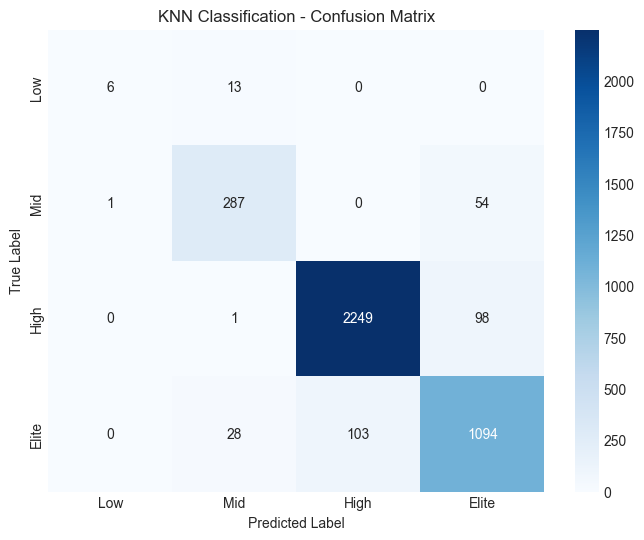

In [51]:
# ==========================================
# KNN Classification - Confusion Matrix
# ==========================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=tier_order,  yticklabels=tier_order)

plt.title('KNN Classification - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Tree-Based Models: Regression & Classification

In [52]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
)


## 4. Assignment 3 Feature & Target Setup

### Why different features from Assignment 2?
- A2 used **all features** with one-hot encoding for Logistic Regression
- A3 Tree-based models are **scale-invariant** — we use 4 numerical features + Position (ordinal-encoded)
- We add a **Regression task** (Value Per M$) which A2 did not attempt

### Targets:
| Task | Target | Type |
|---|---|---|
| Regression | `Value Per M$` | Continuous — player market value |
| Classification | `Value_Class` | Low / Medium / High — value tier |


Regression target:
count    19667.000000
mean         2.514639
std          7.256974
min          0.000000
25%          0.325000
50%          0.675000
75%          1.600000
max        190.500000
Name: Value Per M$, dtype: float64

Classification target:
Value_Class
Low       18582
Medium      989
High         96
Name: count, dtype: int64


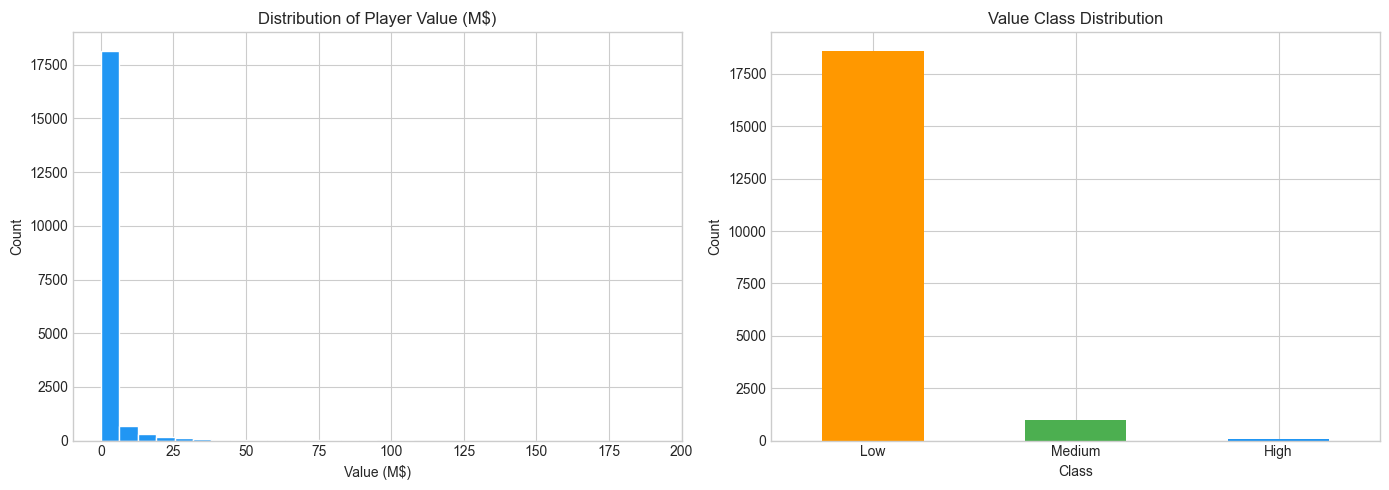

In [53]:
from sklearn.preprocessing import OrdinalEncoder

# Tree-based features: numerical + Position (ordinal encoded)
# Trees are scale-invariant, so Position can be label-encoded effectively
features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Position']
X = df[features].copy()

# Ordinal-encode Position for tree models (handles non-linear relationships)
pos_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X['Position'] = pos_encoder.fit_transform(X[['Position']])

# Regression target
y_reg = df['Value Per M$']

# Classification target (value-based, not rating-based like A2)
df['Value_Class'] = df['Value Per M$'].apply(
    lambda x: 'Low' if x < 10 else ('Medium' if x < 50 else 'High')
)
y_clf = df['Value_Class']

print('Regression target:')
print(y_reg.describe())
print('\nClassification target:')
print(y_clf.value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_reg.hist(bins=30, ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Distribution of Player Value (M$)')
axes[0].set_xlabel('Value (M$)')
axes[0].set_ylabel('Count')

y_clf.value_counts().plot(kind='bar', ax=axes[1],
                           color=['#FF9800','#4CAF50','#2196F3'])
axes[1].set_title('Value Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 5. Why Tree-Based Models for FIFA Data?

### Technical Justification:

| Model | Key Property | Why it fits FIFA Data |
|---|---|---|
| **Decision Tree** | Axis-aligned splits | Discovers thresholds (e.g. *Rating > 85 → High Value*) that are humanly interpretable for scouts |
| **Random Forest** | Bagging + feature subsampling | FIFA features are **correlated** (Rating ↔ Stats Score ↔ Potential). Bagging breaks correlation and reduces variance |
| **Gradient Boosting** | Sequential residual correction | Player value is **right-skewed** (most Low-value players). GB focuses on hard-to-predict high-value outliers |

### Why move beyond Logistic Regression (Assignment 2)?
1. **Non-linearity** — Value does not scale linearly with Rating (an 85→90 jump ≠ a 70→75 jump in market impact)
2. **Feature interactions** — Age × Potential matters differently per position — trees capture this automatically
3. **Skewed target** — Log-normal value distribution violates linear model assumptions
4. **Scale invariance** — No normalization needed, preventing data leakage between folds


## 6. Train/Test Split

In [54]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_train_c, X_test_c, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


Train: 15733 samples | Test: 3934 samples


## 7. Model 1 — Decision Tree

**Role in the system:** Interpretable baseline tree. Scouts can read the split rules directly.

**Risk:** High variance (prone to overfitting) → controlled via `max_depth` and `min_samples_leaf`.


In [55]:
# ── Decision Tree Regression ─────────────────────────────────────────────
dt_reg = DecisionTreeRegressor(random_state=42)
param_dt_reg = {
    'max_depth':        [3, 5, 10, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt_reg = GridSearchCV(dt_reg, param_dt_reg, cv=5, scoring='r2', n_jobs=-1)
grid_dt_reg.fit(X_train, y_train_reg)
best_dt_reg = grid_dt_reg.best_estimator_

y_pred_dt_reg = best_dt_reg.predict(X_test)
r2_dt   = r2_score(y_test_reg, y_pred_dt_reg)
rmse_dt = np.sqrt(mean_squared_error(y_test_reg, y_pred_dt_reg))

print("=== Decision Tree — Regression ===")
print(f"Best Params : {grid_dt_reg.best_params_}")
print(f"R² Score    : {r2_dt:.4f}")
print(f"RMSE        : {rmse_dt:.4f}")


=== Decision Tree — Regression ===
Best Params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
R² Score    : 0.9629
RMSE        : 1.5165


In [56]:
# ── Decision Tree Classification ─────────────────────────────────────────
dt_clf = DecisionTreeClassifier(random_state=42)
param_dt_clf = {
    'max_depth':        [3, 5, 10, None],
    'min_samples_split':[2, 5, 10],
    'criterion':        ['gini', 'entropy']
}
grid_dt_clf = GridSearchCV(dt_clf, param_dt_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt_clf.fit(X_train_c, y_train_clf)
best_dt_clf = grid_dt_clf.best_estimator_

y_pred_dt_clf = best_dt_clf.predict(X_test_c)
acc_dt = accuracy_score(y_test_clf, y_pred_dt_clf)

print("=== Decision Tree — Classification ===")
print(f"Best Params : {grid_dt_clf.best_params_}")
print(f"Accuracy    : {acc_dt:.4f}")
print()
print(classification_report(y_test_clf, y_pred_dt_clf))


=== Decision Tree — Classification ===
Best Params : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
Accuracy    : 0.9959

              precision    recall  f1-score   support

        High       0.88      0.79      0.83        19
         Low       1.00      1.00      1.00      3717
      Medium       0.95      0.97      0.96       198

    accuracy                           1.00      3934
   macro avg       0.94      0.92      0.93      3934
weighted avg       1.00      1.00      1.00      3934



## 8. Model 2 — Random Forest (Bagging)

**Role:** Reduces Decision Tree's high variance by training multiple trees on random data subsets and averaging predictions.

**Advantage for FIFA:** Handles correlated features (Overall_Rating ↔ Total_Stats Score) via random feature subsampling at each split.


In [57]:
# ── Random Forest Regression ─────────────────────────────────────────────
rf_reg = RandomForestRegressor(random_state=42)
param_rf_reg = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5]
}
grid_rf_reg = GridSearchCV(rf_reg, param_rf_reg, cv=5, scoring='r2', n_jobs=-1)
grid_rf_reg.fit(X_train, y_train_reg)
best_rf_reg = grid_rf_reg.best_estimator_

y_pred_rf_reg = best_rf_reg.predict(X_test)
r2_rf   = r2_score(y_test_reg, y_pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))

print("=== Random Forest — Regression ===")
print(f"Best Params : {grid_rf_reg.best_params_}")
print(f"R² Score    : {r2_rf:.4f}")
print(f"RMSE        : {rmse_rf:.4f}")


=== Random Forest — Regression ===
Best Params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
R² Score    : 0.9661
RMSE        : 1.4493


In [58]:
# ── Random Forest Classification ─────────────────────────────────────────
rf_clf = RandomForestClassifier(random_state=42)
param_rf_clf = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5]
}
grid_rf_clf = GridSearchCV(rf_clf, param_rf_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf_clf.fit(X_train_c, y_train_clf)
best_rf_clf = grid_rf_clf.best_estimator_

y_pred_rf_clf = best_rf_clf.predict(X_test_c)
acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)

print("=== Random Forest — Classification ===")
print(f"Best Params : {grid_rf_clf.best_params_}")
print(f"Accuracy    : {acc_rf:.4f}")
print()
print(classification_report(y_test_clf, y_pred_rf_clf))


=== Random Forest — Classification ===
Best Params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy    : 0.9954

              precision    recall  f1-score   support

        High       0.88      0.74      0.80        19
         Low       1.00      1.00      1.00      3717
      Medium       0.94      0.97      0.96       198

    accuracy                           1.00      3934
   macro avg       0.94      0.90      0.92      3934
weighted avg       1.00      1.00      1.00      3934



## 9. Model 3 — Gradient Boosting (Boosting)

**Role:** Sequential error correction — each new tree is trained on the residual errors of the previous ensemble.

**Advantage for FIFA:** Player market value is heavily right-skewed (few extremely expensive players). Gradient Boosting excels at fitting these difficult outlier cases that Random Forest tends to average away.


In [59]:
# ── Gradient Boosting Regression ─────────────────────────────────────────
gb_reg = GradientBoostingRegressor(random_state=42)
param_gb_reg = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5]
}
grid_gb_reg = GridSearchCV(gb_reg, param_gb_reg, cv=5, scoring='r2', n_jobs=-1)
grid_gb_reg.fit(X_train, y_train_reg)
best_gb_reg = grid_gb_reg.best_estimator_

y_pred_gb_reg = best_gb_reg.predict(X_test)
r2_gb   = r2_score(y_test_reg, y_pred_gb_reg)
rmse_gb = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))

print("=== Gradient Boosting — Regression ===")
print(f"Best Params : {grid_gb_reg.best_params_}")
print(f"R² Score    : {r2_gb:.4f}")
print(f"RMSE        : {rmse_gb:.4f}")


=== Gradient Boosting — Regression ===
Best Params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
R² Score    : 0.9795
RMSE        : 1.1267


In [60]:
# ── Gradient Boosting Classification ─────────────────────────────────────
gb_clf = GradientBoostingClassifier(random_state=42)
param_gb_clf = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5]
}
grid_gb_clf = GridSearchCV(gb_clf, param_gb_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb_clf.fit(X_train_c, y_train_clf)
best_gb_clf = grid_gb_clf.best_estimator_

y_pred_gb_clf = best_gb_clf.predict(X_test_c)
acc_gb = accuracy_score(y_test_clf, y_pred_gb_clf)

print("=== Gradient Boosting — Classification ===")
print(f"Best Params : {grid_gb_clf.best_params_}")
print(f"Accuracy    : {acc_gb:.4f}")
print()
print(classification_report(y_test_clf, y_pred_gb_clf))


=== Gradient Boosting — Classification ===
Best Params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Accuracy    : 0.9962

              precision    recall  f1-score   support

        High       0.87      0.68      0.76        19
         Low       1.00      1.00      1.00      3717
      Medium       0.95      0.98      0.96       198

    accuracy                           1.00      3934
   macro avg       0.94      0.89      0.91      3934
weighted avg       1.00      1.00      1.00      3934



## 10. Individual Model Comparison

            Model  Regression R²  Regression RMSE  Classification Accuracy
    Decision Tree         0.9629           1.5165                   0.9959
    Random Forest         0.9661           1.4493                   0.9954
Gradient Boosting         0.9795           1.1267                   0.9962


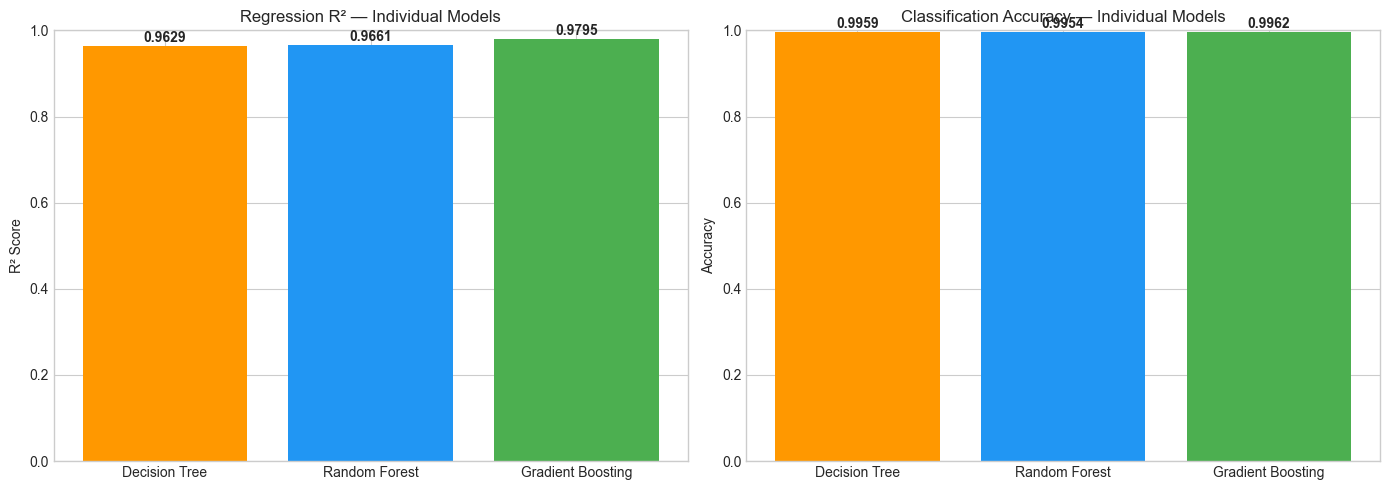

In [61]:
# Summary table for all 3 models
results_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Regression R²':  [round(r2_dt,4),  round(r2_rf,4),  round(r2_gb,4)],
    'Regression RMSE':[round(rmse_dt,4),round(rmse_rf,4),round(rmse_gb,4)],
    'Classification Accuracy': [round(acc_dt,4), round(acc_rf,4), round(acc_gb,4)]
})
print(results_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF9800', '#2196F3', '#4CAF50']
models_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting']

axes[0].bar(models_names, [r2_dt, r2_rf, r2_gb], color=colors)
axes[0].set_title('Regression R² — Individual Models')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate([r2_dt, r2_rf, r2_gb]):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(models_names, [acc_dt, acc_rf, acc_gb], color=colors)
axes[1].set_title('Classification Accuracy — Individual Models')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
for i, v in enumerate([acc_dt, acc_rf, acc_gb]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 11. Bias-Variance Diagnosis — Learning Curves

**How to read:**
- **High Bias (Underfitting):** Both train & validation scores are low and close together
- **High Variance (Overfitting):** Train score is high, large gap vs validation score
- **Good Fit:** Both scores converge to a high value


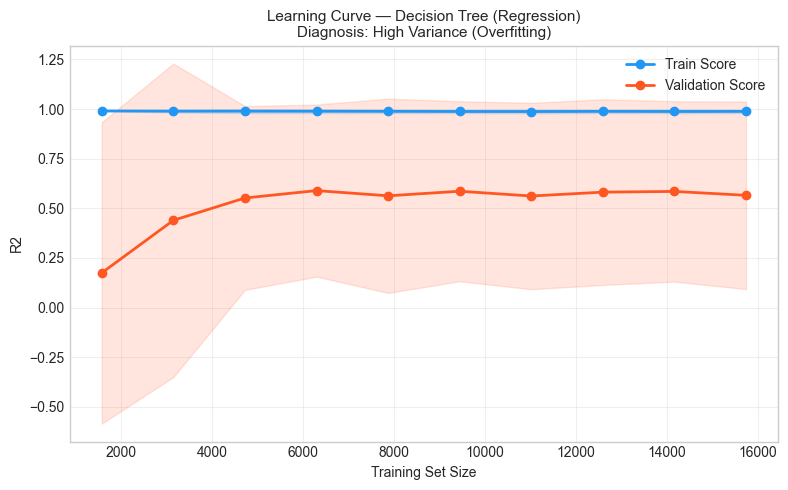

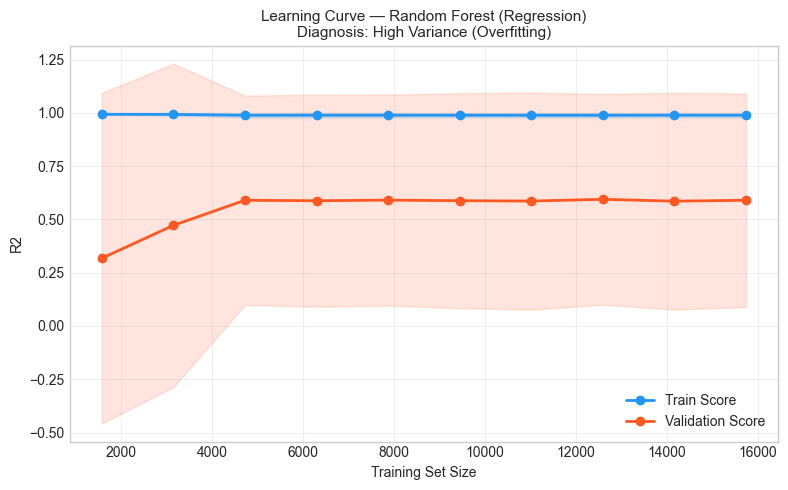

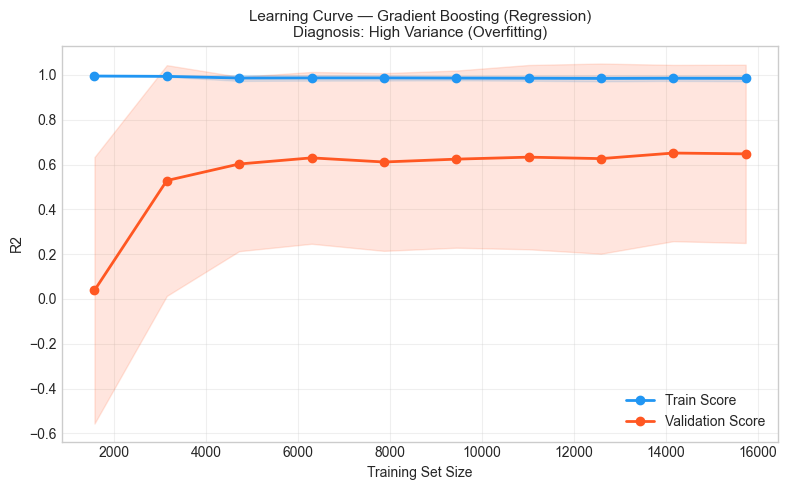

In [62]:
def plot_learning_curve(model, X, y, title, scoring='r2', cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean   = np.mean(val_scores,   axis=1)
    train_std  = np.std(train_scores,  axis=1)
    val_std    = np.std(val_scores,    axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Train Score',      color='#2196F3', lw=2)
    plt.plot(train_sizes, val_mean,   'o-', label='Validation Score', color='#FF5722', lw=2)
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#2196F3')
    plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.15, color='#FF5722')

    gap = abs(train_mean[-1] - val_mean[-1])
    diagnosis = "High Variance (Overfitting)" if gap > 0.1 else                 ("High Bias (Underfitting)" if val_mean[-1] < 0.6 else "Good Fit")
    plt.title(f'Learning Curve — {title}\nDiagnosis: {diagnosis}', fontsize=11)
    plt.xlabel('Training Set Size')
    plt.ylabel(scoring.upper())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Regression
plot_learning_curve(best_dt_reg, X, y_reg, "Decision Tree (Regression)")
plot_learning_curve(best_rf_reg, X, y_reg, "Random Forest (Regression)")
plot_learning_curve(best_gb_reg, X, y_reg, "Gradient Boosting (Regression)")


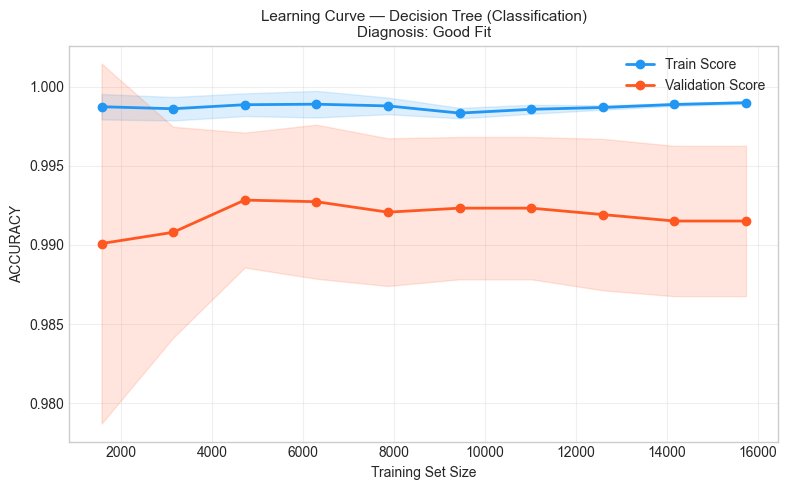

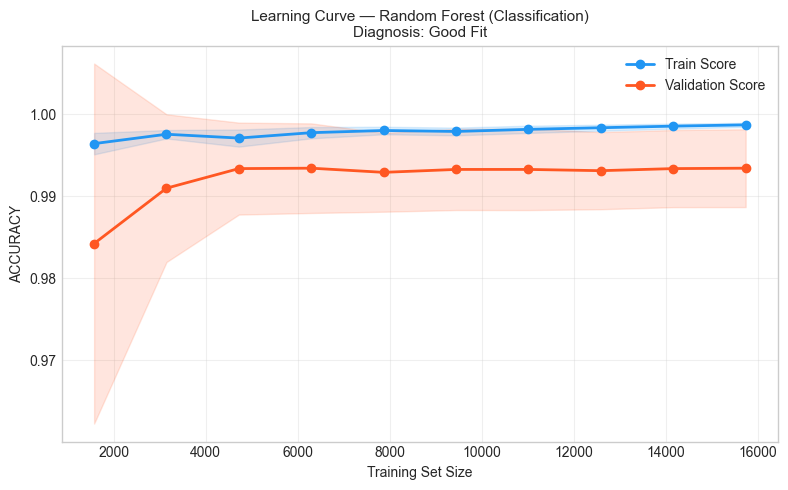

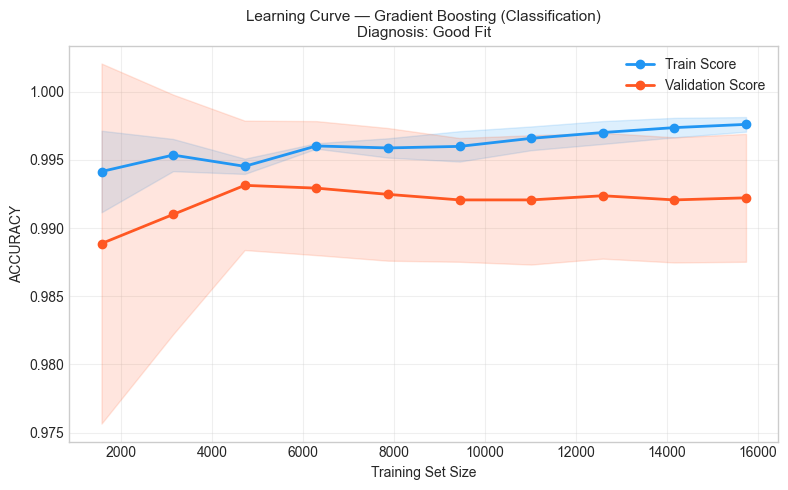

In [63]:
# Classification
plot_learning_curve(best_dt_clf,  X, y_clf, "Decision Tree (Classification)",      scoring='accuracy')
plot_learning_curve(best_rf_clf,  X, y_clf, "Random Forest (Classification)",      scoring='accuracy')
plot_learning_curve(best_gb_clf,  X, y_clf, "Gradient Boosting (Classification)",  scoring='accuracy')


#### Ensemble Learning Techniques
 

In [79]:
from sklearn.ensemble import (
    VotingRegressor, VotingClassifier,
    StackingRegressor, StackingClassifier,
    BaggingRegressor, BaggingClassifier,
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
print("Ensemble imports ready ✓")


Ensemble imports ready ✓


In [80]:
# ─── unified evaluation helper (reuse evaluate_regression / evaluate_classification)
def cv_stability(model, X, y, scoring, cv=5):
    """Return mean ± std of cross-val score (stability proof)."""
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return scores.mean(), scores.std()


In [81]:
# ─── Voting Classifier ───────────────────────────────────────────────────────
voting_clf_hard = VotingClassifier(
    estimators=[
        ('dt',  best_dt_clf),
        ('rf',  best_rf_clf),
        ('gb',  best_gb_clf),
    ],
    voting='hard',
    n_jobs=-1
)

voting_clf_soft = VotingClassifier(
    estimators=[
        ('dt',  best_dt_clf),
        ('rf',  best_rf_clf),
        ('gb',  best_gb_clf),
    ],
    voting='soft',
    n_jobs=-1
)

# Train
voting_clf_hard.fit(X_train_c, y_train_clf)
voting_clf_soft.fit(X_train_c, y_train_clf)

# Evaluate
y_pred_vh = voting_clf_hard.predict(X_test_c)
y_pred_vs = voting_clf_soft.predict(X_test_c)

acc_vh = accuracy_score(y_test_clf, y_pred_vh)
acc_vs = accuracy_score(y_test_clf, y_pred_vs)

print("=== Voting Classifier — Hard ===")
print(f"Accuracy : {acc_vh:.4f}")
print()
print("=== Voting Classifier — Soft ===")
print(f"Accuracy : {acc_vs:.4f}")


=== Voting Classifier — Hard ===
Accuracy : 0.9967

=== Voting Classifier — Soft ===
Accuracy : 0.9962


In [82]:
# Classification report for best voting variant
best_voting_clf = voting_clf_soft if acc_vs >= acc_vh else voting_clf_hard
best_voting_label = 'Soft' if acc_vs >= acc_vh else 'Hard'
y_pred_best_vc = y_pred_vs if acc_vs >= acc_vh else y_pred_vh

print(f"Best Voting Variant: {best_voting_label}")
print()
print(classification_report(y_test_clf, y_pred_best_vc))


Best Voting Variant: Hard

              precision    recall  f1-score   support

        High       0.88      0.79      0.83        19
         Low       1.00      1.00      1.00      3717
      Medium       0.95      0.98      0.97       198

    accuracy                           1.00      3934
   macro avg       0.94      0.92      0.93      3934
weighted avg       1.00      1.00      1.00      3934



In [83]:
# ─── Voting Regressor ────────────────────────────────────────────────────────
voting_reg = VotingRegressor(
    estimators=[
        ('dt', best_dt_reg),
        ('rf', best_rf_reg),
        ('gb', best_gb_reg),
    ],
    n_jobs=-1
)

voting_reg.fit(X_train, y_train_reg)
y_pred_vr = voting_reg.predict(X_test)

r2_vr   = r2_score(y_test_reg, y_pred_vr)
rmse_vr = np.sqrt(mean_squared_error(y_test_reg, y_pred_vr))

print("=== Voting Regressor ===")
print(f"R² Score : {r2_vr:.4f}")
print(f"RMSE     : {rmse_vr:.4f}")


=== Voting Regressor ===
R² Score : 0.9750
RMSE     : 1.2454


In [84]:
# ─── Stacking Classifier ─────────────────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[
        ('dt', best_dt_clf),
        ('rf', best_rf_clf),
        ('gb', best_gb_clf),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,                     # out-of-fold strategy to prevent leakage
    passthrough=False,        # meta-learner sees only base predictions
    n_jobs=-1
)

stacking_clf.fit(X_train_c, y_train_clf)
y_pred_sc = stacking_clf.predict(X_test_c)
acc_sc = accuracy_score(y_test_clf, y_pred_sc)

print("=== Stacking Classifier ===")
print(f"Accuracy : {acc_sc:.4f}")
print()
print(classification_report(y_test_clf, y_pred_sc))


=== Stacking Classifier ===
Accuracy : 0.9962

              precision    recall  f1-score   support

        High       0.88      0.74      0.80        19
         Low       1.00      1.00      1.00      3717
      Medium       0.95      0.97      0.96       198

    accuracy                           1.00      3934
   macro avg       0.94      0.90      0.92      3934
weighted avg       1.00      1.00      1.00      3934



In [85]:
# ─── Stacking Regressor ──────────────────────────────────────────────────────
stacking_reg = StackingRegressor(
    estimators=[
        ('dt', best_dt_reg),
        ('rf', best_rf_reg),
        ('gb', best_gb_reg),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacking_reg.fit(X_train, y_train_reg)
y_pred_sr = stacking_reg.predict(X_test)

r2_sr   = r2_score(y_test_reg, y_pred_sr)
rmse_sr = np.sqrt(mean_squared_error(y_test_reg, y_pred_sr))

print("=== Stacking Regressor ===")
print(f"R² Score : {r2_sr:.4f}")
print(f"RMSE     : {rmse_sr:.4f}")


=== Stacking Regressor ===
R² Score : 0.9799
RMSE     : 1.1169


In [86]:
# ─── CV Stability — Classification ──────────────────────────────────────────
clf_models = {
    'Decision Tree'    : best_dt_clf,
    'Random Forest'    : best_rf_clf,
    'Gradient Boosting': best_gb_clf,
    'Voting (soft)'    : voting_clf_soft,
    'Stacking'         : stacking_clf,
}

print("=" * 55)
print(f"{'Model':<22} {'CV Mean':>10} {'CV Std':>10}  Verdict")
print("=" * 55)

cv_clf_results = {}
for name, model in clf_models.items():
    mean, std = cv_stability(model, X_train_c.tolist() if hasattr(X_train_c, 'tolist') else X_train_c,
                              y_train_clf, scoring='accuracy')
    verdict = "Stable ✓" if std < 0.02 else ("Moderate" if std < 0.05 else "Unstable ✗")
    cv_clf_results[name] = {'mean': mean, 'std': std}
    print(f"{name:<22} {mean:>10.4f} {std:>10.4f}  {verdict}")

print("=" * 55)


Model                     CV Mean     CV Std  Verdict
Decision Tree              0.9937     0.0012  Stable ✓
Random Forest              0.9956     0.0010  Stable ✓
Gradient Boosting          0.9952     0.0014  Stable ✓
Voting (soft)              0.9948     0.0009  Stable ✓
Stacking                   0.9950     0.0010  Stable ✓


In [87]:
# ─── CV Stability — Regression ───────────────────────────────────────────────
reg_models = {
    'Decision Tree'    : best_dt_reg,
    'Random Forest'    : best_rf_reg,
    'Gradient Boosting': best_gb_reg,
    'Voting Regressor' : voting_reg,
    'Stacking'         : stacking_reg,
}

print("=" * 55)
print(f"{'Model':<22} {'CV Mean':>10} {'CV Std':>10}  Verdict")
print("=" * 55)

cv_reg_results = {}
for name, model in reg_models.items():
    mean, std = cv_stability(model, X_train, y_train_reg, scoring='r2')
    verdict = "Stable ✓" if std < 0.02 else ("Moderate" if std < 0.05 else "Unstable ✗")
    cv_reg_results[name] = {'mean': mean, 'std': std}
    print(f"{name:<22} {mean:>10.4f} {std:>10.4f}  {verdict}")

print("=" * 55)


Model                     CV Mean     CV Std  Verdict
Decision Tree              0.9430     0.0330  Moderate
Random Forest              0.9527     0.0357  Moderate
Gradient Boosting          0.9650     0.0244  Moderate
Voting Regressor           0.9592     0.0310  Moderate
Stacking                   0.9630     0.0261  Moderate


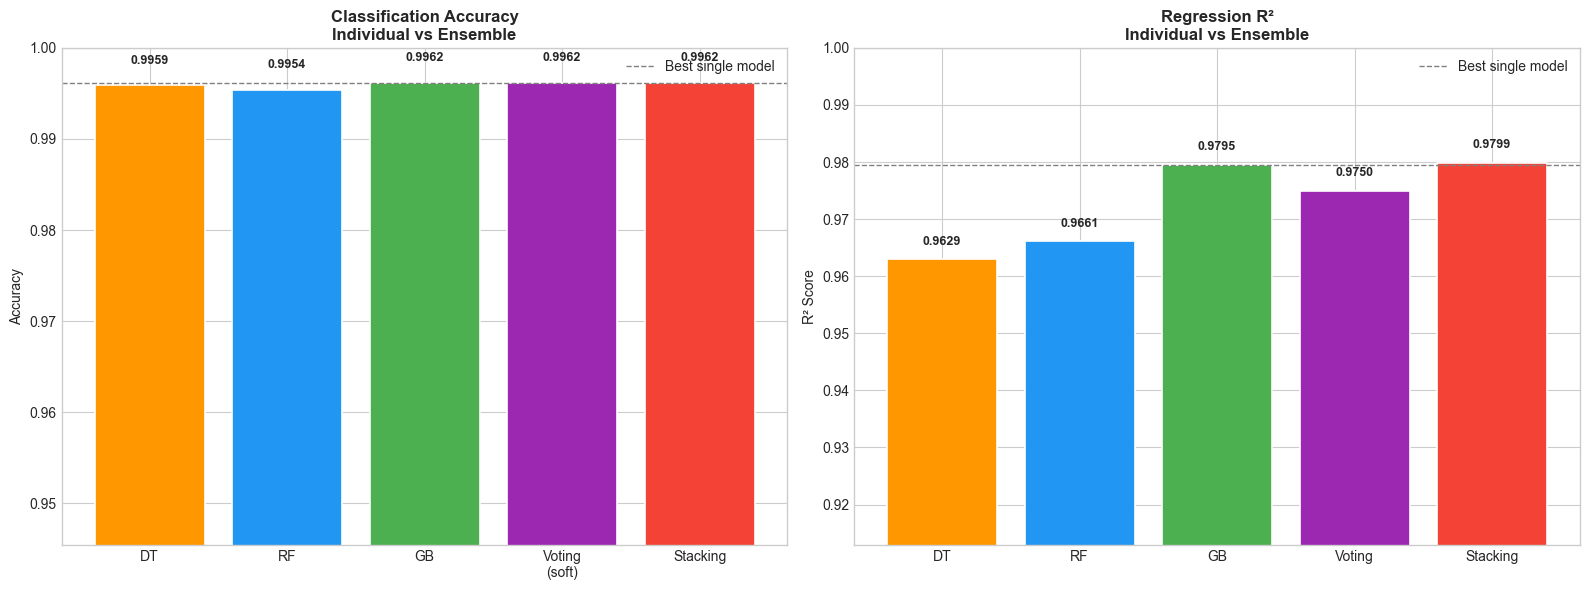

In [88]:
# ─── Combined Bar Chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification accuracy
clf_names  = ['DT', 'RF', 'GB', 'Voting\n(soft)', 'Stacking']
clf_accs   = [acc_dt, acc_rf, acc_gb,
              acc_vs, acc_sc]
clf_colors = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0', '#F44336']

bars0 = axes[0].bar(clf_names, clf_accs, color=clf_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Classification Accuracy\nIndividual vs Ensemble', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(min(clf_accs) - 0.05, 1.0)
axes[0].axhline(max(acc_dt, acc_rf, acc_gb), color='gray', linestyle='--', linewidth=1, label='Best single model')
axes[0].legend()
for bar, val in zip(bars0, clf_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Regression R²
reg_names  = ['DT', 'RF', 'GB', 'Voting', 'Stacking']
reg_r2s    = [r2_dt, r2_rf, r2_gb, r2_vr, r2_sr]

bars1 = axes[1].bar(reg_names, reg_r2s, color=clf_colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Regression R²\nIndividual vs Ensemble', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(min(reg_r2s) - 0.05, 1.0)
axes[1].axhline(max(r2_dt, r2_rf, r2_gb), color='gray', linestyle='--', linewidth=1, label='Best single model')
axes[1].legend()
for bar, val in zip(bars1, reg_r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


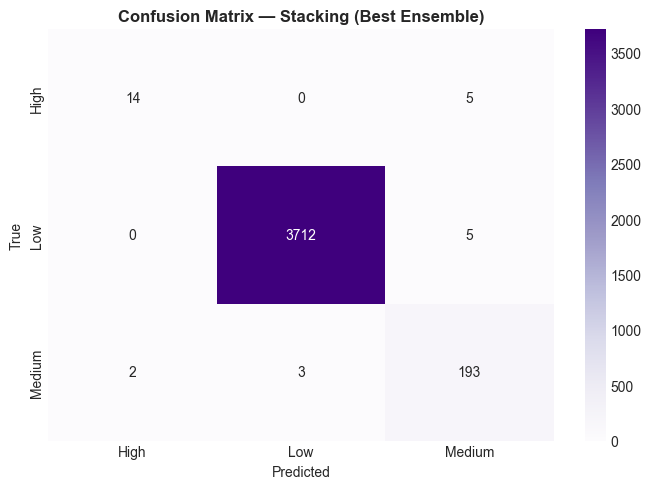

In [89]:
# ─── Confusion Matrix — Best Ensemble Classifier ─────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_ens_pred = y_pred_sc if acc_sc >= acc_vs else y_pred_best_vc
best_ens_name = 'Stacking' if acc_sc >= acc_vs else f'Voting ({best_voting_label})'

cm_ens = confusion_matrix(y_test_clf, best_ens_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])
plt.title(f'Confusion Matrix — {best_ens_name} (Best Ensemble)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


In [90]:
# ─── Unified Inference Function ──────────────────────────────────────────────
def scout_player(player_dict: dict,
                 reg_model=stacking_reg,
                 clf_model=stacking_clf,
                 pos_enc=pos_encoder) -> dict:
    """
    Accept a raw player profile and return valuation + performance tier.

    Parameters
    ----------
    player_dict : dict  e.g. {'Age':25, 'Overall_Rating':82,
                               'Future Potential':88,
                               'Total_Stats Score':300, 'Position':'ST'}
    Returns
    -------
    dict with keys: predicted_value_M, performance_tier
    """
    import pandas as pd, numpy as np

    # Build DataFrame (single row)
    row = pd.DataFrame([player_dict])

    # Encode position the same way as training
    row['Position'] = pos_enc.transform(row[['Position']])

    features = ['Age', 'Overall_Rating', 'Future Potential',
                'Total_Stats Score', 'Position']
    X_new = row[features]

    val_pred  = reg_model.predict(X_new)[0]
    tier_pred = clf_model.predict(X_new)[0]

    return {
        'predicted_value_M$': round(float(val_pred), 2),
        'performance_tier'  : tier_pred
    }

# ─── Demo ─────────────────────────────────────────────────────────────────────
example_players = [
    {'Age': 22, 'Overall_Rating': 88, 'Future Potential': 94,
     'Total_Stats Score': 350, 'Position': 'ST',  'label': 'Young Star'},
    {'Age': 31, 'Overall_Rating': 75, 'Future Potential': 76,
     'Total_Stats Score': 265, 'Position': 'CM',  'label': 'Veteran Mid'},
    {'Age': 18, 'Overall_Rating': 65, 'Future Potential': 82,
     'Total_Stats Score': 210, 'Position': 'LW',  'label': 'Youth Prospect'},
]

print("=" * 50)
print("  UNIFIED SCOUTING SYSTEM — DEMO")
print("=" * 50)
for p in example_players:
    label = p.pop('label')
    result = scout_player(p)
    p['label'] = label
    print(f"\n  {label}")
    print(f"  Age: {p['Age']}  Rating: {p['Overall_Rating']}  "
          f"Potential: {p['Future Potential']}  Position: {p['Position']}")
    print(f"  → Predicted Value : {result['predicted_value_M$']} M$")
    print(f"  → Performance Tier: {result['performance_tier']}")
print()
print("=" * 50)


  UNIFIED SCOUTING SYSTEM — DEMO

  Young Star
  Age: 22  Rating: 88  Potential: 94  Position: ST
  → Predicted Value : 132.15 M$
  → Performance Tier: High

  Veteran Mid
  Age: 31  Rating: 75  Potential: 76  Position: CM
  → Predicted Value : 2.95 M$
  → Performance Tier: Low

  Youth Prospect
  Age: 18  Rating: 65  Potential: 82  Position: LW
  → Predicted Value : 1.7 M$
  → Performance Tier: Low



In [ ]:
import json

results = {
    "group_members": [
        # TODO: Fill in your group members
        {"ِAhmed Hassan Mohamed": "Member 1", "2401247856": "ID1"},
        {"Yousef Mahmoud Abdu": "Member 2", "2401241376": "ID2"},
        {"Yousef Shiref ": "Member 3", "2401248761": "ID3"},
        {"Mostafa Ashraf Ragab": "Member 4", "2401248097": "ID4"},
        {"Mostafa Mahmoud Mohamed": "Member 5", "2401244790": "ID5"},
    ],
    "best_hyperparameters": {
        "decision_tree_reg" : grid_dt_reg.best_params_,
        "decision_tree_clf" : grid_dt_clf.best_params_,
        "random_forest_reg" : grid_rf_reg.best_params_,
        "random_forest_clf" : grid_rf_clf.best_params_,
        "gradient_boost_reg": grid_gb_reg.best_params_,
        "gradient_boost_clf": grid_gb_clf.best_params_,
    },
    "cv_stability": {
        "classification": {
            name: {"mean": round(v["mean"], 4), "std": round(v["std"], 4)}
            for name, v in cv_clf_results.items()
        },
        "regression": {
            name: {"mean": round(v["mean"], 4), "std": round(v["std"], 4)}
            for name, v in cv_reg_results.items()
        }
    },
    "test_performance": {
        "classification": {
            "decision_tree"    : round(acc_dt, 4),
            "random_forest"    : round(acc_rf, 4),
            "gradient_boosting": round(acc_gb, 4),
            "voting_soft"      : round(acc_vs, 4),
            "stacking"         : round(acc_sc, 4),
        },
        "regression": {
            "decision_tree"    : round(r2_dt, 4),
            "random_forest"    : round(r2_rf, 4),
            "gradient_boosting": round(r2_gb, 4),
            "voting"           : round(r2_vr, 4),
            "stacking"         : round(r2_sr, 4),
        }
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("results.json saved ✓")
print(json.dumps(results, indent=2))
